# Round 4 — Counterparty Analysis & Options Mean Reversion

**Products:** HYDROGEL_PACK (limit 200), VELVETFRUIT_EXTRACT (limit 200), 10 × VEV calls (limit 300 each)  
**TTE:** options start at 4 days on Day 1 timestamp 0, decay to ~1 day by end of Day 3  
**Traders:** Mark 01, 14, 22, 38, 49, 55, 67 (full counterparty visibility in Round 4)

**Structure**
1. Market Overview
2. All-Trader Analysis (summary, volume, PnL, positions, counterparty matrix)
3. Deep Dive: Mark 14 (HG + VEV_4000 heavy hitter)
4. Deep Dive: Mark 38 (Mark 14's primary counterparty)
5. Deep Dive: Mark 67 (pure VELVET buyer — informed trader?)
6. Options Price Series Analysis (stationarity, ACF, half-life, residuals vs BS fair)
7. Mean Reversion Backtest (respects position limits)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import warnings, math
from collections import defaultdict
warnings.filterwarnings('ignore')

try:
    from statsmodels.tsa.stattools import adfuller
    from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
    import statsmodels.api as sm
    HAS_SM = True
except ImportError:
    HAS_SM = False
    print('statsmodels not found — install with: pip install statsmodels')

plt.rcParams.update({
    'figure.dpi': 110, 'axes.grid': True, 'grid.alpha': 0.3,
    'font.size': 9, 'axes.spines.top': False, 'axes.spines.right': False,
})

# ── paths & identifiers ──────────────────────────────────────────────────────
DATA_DIR = '/Users/pirey/Dropbox/imc-prosperity-4/ROUND_4'
DAYS = [1, 2, 3]
TPD = 1_000_000          # timestamp units per game-day (0 to 999_900 in steps of 100)

HYDRO  = 'HYDROGEL_PACK'
VELVET = 'VELVETFRUIT_EXTRACT'
STRIKES = [4000, 4500, 5000, 5100, 5200, 5300, 5400, 5500, 6000, 6500]
OPTIONS = [f'VEV_{k}' for k in STRIKES]
ALL_PRODUCTS = [HYDRO, VELVET] + OPTIONS
LIMITS = {HYDRO: 200, VELVET: 200, **{o: 300 for o in OPTIONS}}

TRADERS = ['Mark 01', 'Mark 14', 'Mark 22', 'Mark 38', 'Mark 49', 'Mark 55', 'Mark 67']
KEY_TRADERS = ['Mark 14', 'Mark 38', 'Mark 67']

COLORS = dict(zip(TRADERS, [
    '#1f77b4', '#d62728', '#ff7f0e', '#2ca02c', '#9467bd', '#8c564b', '#e377c2'
]))

# ── Black-Scholes helpers ────────────────────────────────────────────────────
SQRT_365 = math.sqrt(365.0)
SA, SB, SC = 0.086020, -0.000806, 0.012536  # daily smile: sigma_daily = SA*x^2 + SB*x + SC

def _ncdf(x):
    return 0.5 * math.erfc(-x / math.sqrt(2.0))

def bs_call(spot, strike, t_years, sigma):
    if spot <= 0 or strike <= 0 or t_years <= 0 or sigma < 1e-9:
        return max(spot - strike, 0.0)
    scaled = sigma * math.sqrt(t_years)
    if scaled < 1e-9:
        return max(spot - strike, 0.0)
    d1 = (math.log(spot / strike) + 0.5 * sigma**2 * t_years) / scaled
    d2 = d1 - scaled
    return spot * _ncdf(d1) - strike * _ncdf(d2)

def bs_delta(spot, strike, t_years, sigma):
    if spot <= 0 or strike <= 0 or t_years <= 0 or sigma < 1e-9:
        return 1.0 if spot > strike else 0.0
    scaled = sigma * math.sqrt(t_years)
    if scaled < 1e-9:
        return 1.0 if spot > strike else 0.0
    d1 = (math.log(spot / strike) + 0.5 * sigma**2 * t_years) / scaled
    return _ncdf(d1)

def static_sigma(spot, strike):
    x = math.log(max(spot, 1.0) / max(strike, 1.0))
    return max(0.05, (SA * x * x + SB * x + SC) * SQRT_365)

def tte_years(day, ts):
    '''TTE in years at (game day, timestamp). TTE=4 days at day=1, ts=0.'''
    remaining_days = 4.0 - (day - 1) - ts / TPD
    return max(remaining_days, 0.001) / 365.0

print('Setup complete.')

Setup complete.


In [2]:
# ── Data loading ─────────────────────────────────────────────────────────────

def load_trades():
    frames = []
    for d in DAYS:
        df = pd.read_csv(f'{DATA_DIR}/trades_round_4_day_{d}.csv', sep=';')
        df.columns = df.columns.str.lower()
        df['day'] = d
        df['global_ts'] = (d - 1) * TPD + df['timestamp']
        frames.append(df)
    return pd.concat(frames, ignore_index=True)

def load_prices():
    frames = []
    for d in DAYS:
        df = pd.read_csv(f'{DATA_DIR}/prices_round_4_day_{d}.csv', sep=';')
        df.columns = df.columns.str.lower()
        df['day'] = d
        df['global_ts'] = (d - 1) * TPD + df['timestamp']
        frames.append(df)
    return pd.concat(frames, ignore_index=True)

trades = load_trades()
prices = load_prices()

# Mid-price lookup: index=global_ts, columns=product
mid_wide = (
    prices.pivot_table(index='global_ts', columns='product', values='mid_price')
    .sort_index()
    .ffill()
)

print(f'Trades : {len(trades):,} rows | Days: {DAYS}')
print(f'Prices : {len(prices):,} rows | {prices["product"].nunique()} products x {prices["global_ts"].nunique():,} timestamps')
print(f'\nAll traders in data:')
buyer_c  = trades['buyer'].value_counts()
seller_c = trades['seller'].value_counts()
total_c  = buyer_c.add(seller_c, fill_value=0).sort_values(ascending=False)
print(total_c[total_c.index.isin(TRADERS)].rename('trade_rows').to_frame())

Trades : 4,281 rows | Days: [1, 2, 3]
Prices : 360,000 rows | 12 products x 30,000 timestamps

All traders in data:
         trade_rows
Mark 14      2172.0
Mark 01      1843.0
Mark 22      1584.0
Mark 38      1478.0
Mark 55      1198.0
Mark 67       165.0
Mark 49       122.0


## 1. Market Overview

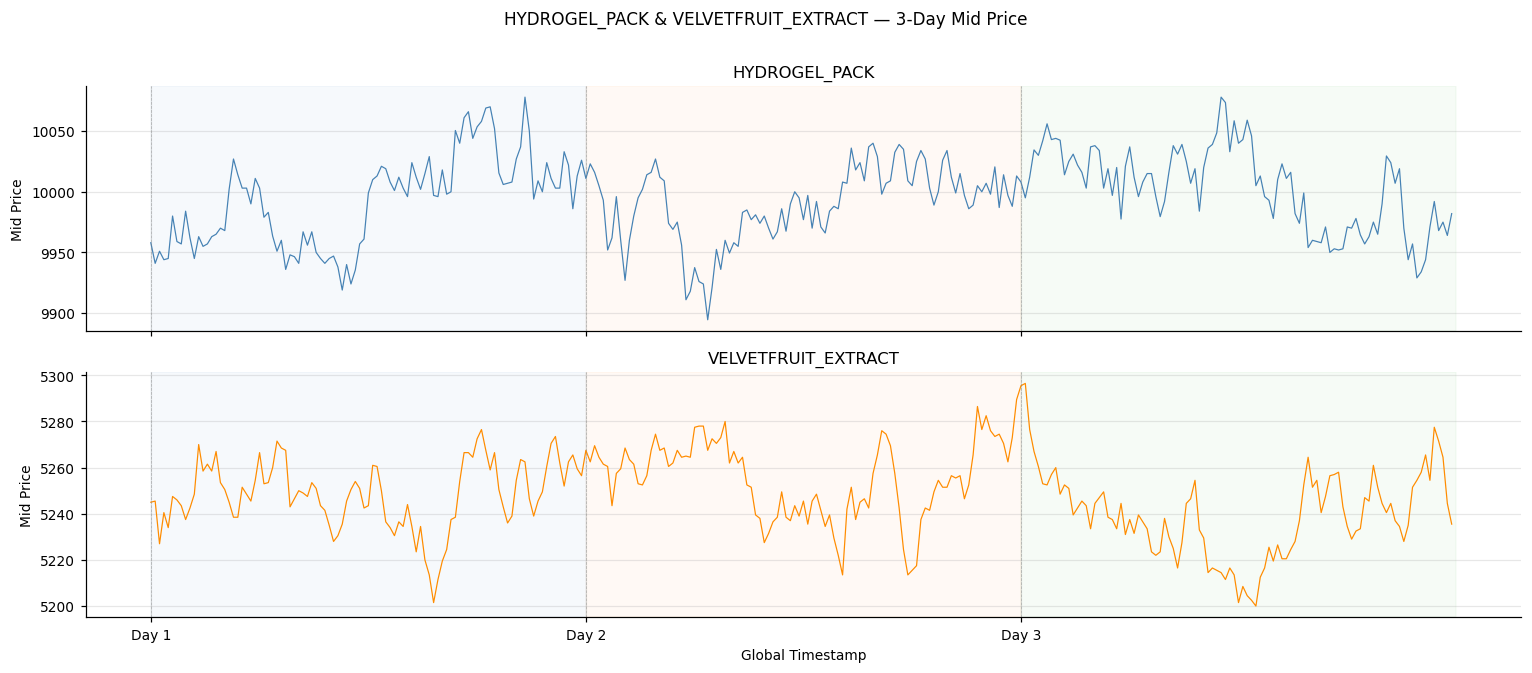

In [3]:
fig, axes = plt.subplots(2, 1, figsize=(14, 6), sharex=True)
day_starts = [(d - 1) * TPD for d in DAYS]

for ax, product, color in zip(axes, [HYDRO, VELVET], ['steelblue', 'darkorange']):
    if product not in mid_wide.columns:
        continue
    pdata = mid_wide[product].dropna().iloc[::100]  # downsample to every 10s
    ax.plot(pdata.index, pdata.values, color=color, lw=0.8)
    for i, ds in enumerate(day_starts):
        ax.axvspan(ds, ds + TPD, alpha=0.04, color=f'C{i}')
        ax.axvline(ds, color='gray', lw=0.5, ls='--', alpha=0.5)
    ax.set_ylabel('Mid Price')
    ax.set_title(product)

axes[-1].set_xlabel('Global Timestamp')
axes[-1].set_xticks(day_starts)
axes[-1].set_xticklabels([f'Day {d}' for d in DAYS])
plt.suptitle('HYDROGEL_PACK & VELVETFRUIT_EXTRACT — 3-Day Mid Price', fontsize=11, y=1.01)
plt.tight_layout()
plt.show()

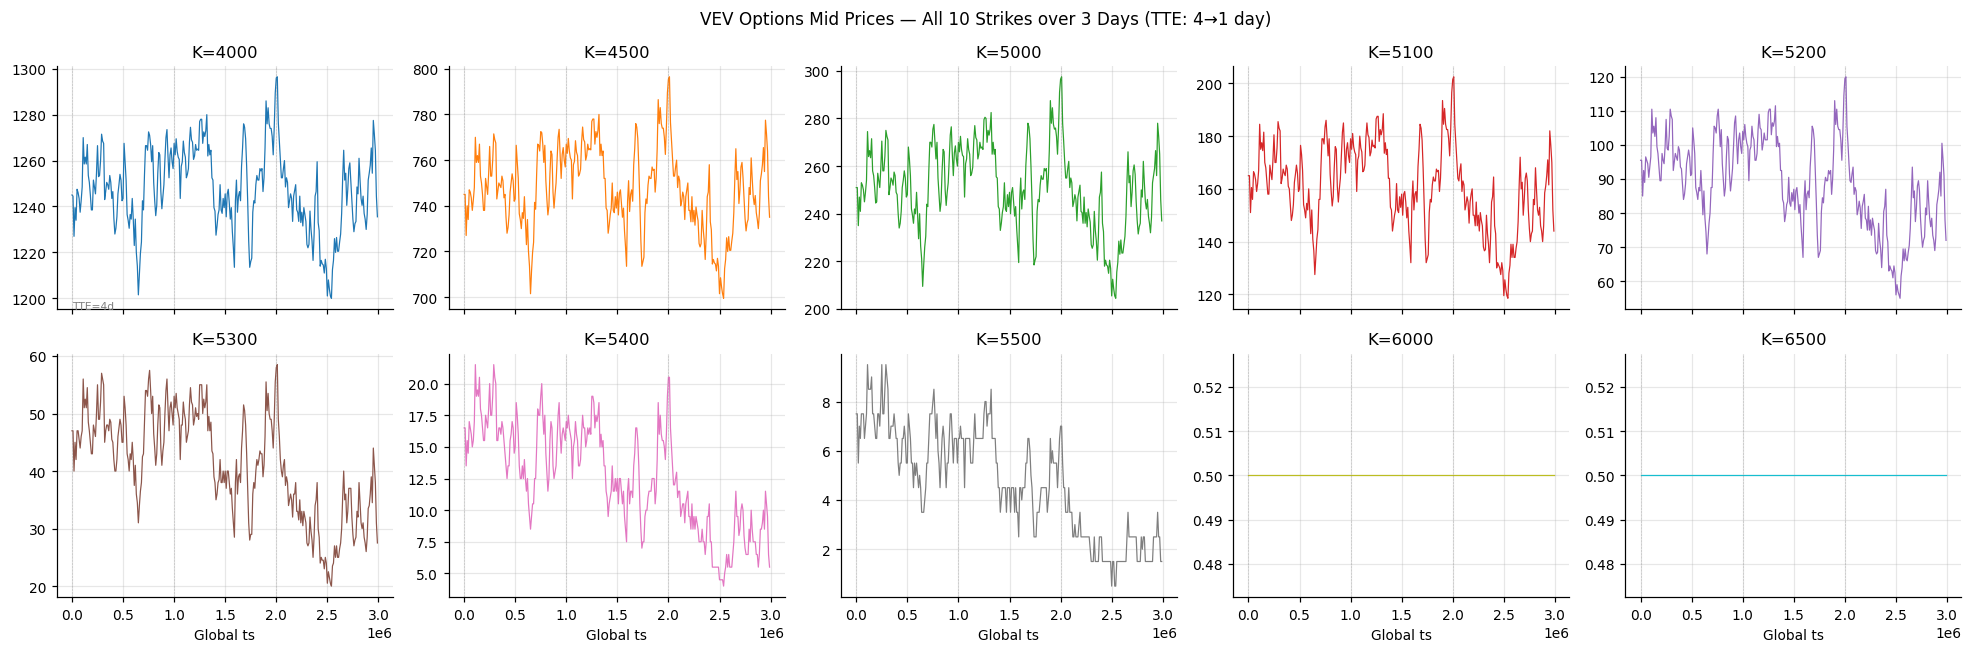

In [4]:
fig, axes = plt.subplots(2, 5, figsize=(18, 6), sharex=True)
axes = axes.flatten()

for i, (strike, ax) in enumerate(zip(STRIKES, axes)):
    opt = f'VEV_{strike}'
    if opt not in mid_wide.columns:
        ax.set_title(f'K={strike} (no data)')
        continue
    pdata = mid_wide[opt].dropna().iloc[::100]
    ax.plot(pdata.index, pdata.values, lw=0.8, color=f'C{i}')
    for ds in day_starts:
        ax.axvline(ds, color='gray', lw=0.4, ls='--', alpha=0.4)
    ax.set_title(f'K={strike}')

for ax in axes[5:]:
    ax.set_xlabel('Global ts')

# Add TTE annotation
axes[0].annotate('TTE=4d', xy=(0, axes[0].get_ylim()[0]), fontsize=7, color='gray')

plt.suptitle('VEV Options Mid Prices — All 10 Strikes over 3 Days (TTE: 4→1 day)', fontsize=11)
plt.tight_layout()
plt.show()

## 2. All-Trader Analysis

We analyse all 7 traders first: summary, counterparty flows, positions, and MtM PnL.

In [5]:
# Build one event row per (trader, trade side)
# BUY: +qty, negative cash flow; SELL: -qty, positive cash flow
events_rows = []
for _, row in trades.iterrows():
    for side, agent in [('BUY', row['buyer']), ('SELL', row['seller'])]:
        if agent not in TRADERS:
            continue
        sq = row['quantity'] if side == 'BUY' else -row['quantity']
        cf = -row['price'] * row['quantity'] if side == 'BUY' else row['price'] * row['quantity']
        events_rows.append({
            'trader'   : agent,
            'global_ts': row['global_ts'],
            'day'      : row['day'],
            'symbol'   : row['symbol'],
            'side'     : side,
            'price'    : row['price'],
            'quantity' : row['quantity'],
            'signed_qty': sq,
            'cash_flow': cf,
        })

events = pd.DataFrame(events_rows).sort_values('global_ts').reset_index(drop=True)
print(f'Trade events (one per trader×side): {len(events):,}')
print(f'\nSide breakdown per trader:')
print(events.groupby(['trader', 'side'])['quantity'].agg(['sum', 'count']).rename(columns={'sum': 'volume', 'count': 'trades'}))

Trade events (one per trader×side): 8,562

Side breakdown per trader:
              volume  trades
trader  side                
Mark 01 BUY     6053    1599
        SELL    1375     244
Mark 14 BUY     4510    1127
        SELL    4208    1045
Mark 22 BUY      206      42
        SELL    5683    1542
Mark 38 BUY     2493     733
        SELL    2507     745
Mark 49 BUY      115      17
        SELL    1071     105
Mark 55 BUY     3254     598
        SELL    3297     600
Mark 67 BUY     1510     165


In [6]:
# Volume traded per trader per product (one-sided, i.e. buy+sell counted separately)
vol_table = (
    events.groupby(['trader', 'symbol'])['quantity'].sum()
    .unstack(fill_value=0)
)
# Reorder columns
col_order = [c for c in [HYDRO, VELVET] + OPTIONS if c in vol_table.columns]
vol_table = vol_table[col_order]
vol_table['TOTAL'] = vol_table.sum(axis=1)
vol_table = vol_table.sort_values('TOTAL', ascending=False)

print('Volume Traded per Trader per Product (buy + sell combined):')
display(vol_table.style
    .background_gradient(cmap='YlOrRd', axis=None, subset=col_order)
    .format('{:,.0f}'))

Volume Traded per Trader per Product (buy + sell combined):


symbol,HYDROGEL_PACK,VELVETFRUIT_EXTRACT,VEV_4000,VEV_4500,VEV_5000,VEV_5100,VEV_5200,VEV_5300,VEV_5400,VEV_5500,VEV_6000,VEV_6500,TOTAL
trader,,,,,,,,,,,,,
Mark 14,"4,022","3,524",870,0,0,0,122,105,48,27,0,0,"8,718"
Mark 01,0,"2,792",0,0,0,0,34,439,911,"1,042","1,105","1,105","7,428"
Mark 55,0,"6,551",0,0,0,0,0,0,0,0,0,0,"6,551"
Mark 22,74,843,6,6,6,6,162,548,959,"1,069","1,105","1,105","5,889"
Mark 38,"4,096",0,876,6,6,6,6,4,0,0,0,0,"5,000"
Mark 67,0,"1,510",0,0,0,0,0,0,0,0,0,0,"1,510"
Mark 49,0,"1,186",0,0,0,0,0,0,0,0,0,0,"1,186"


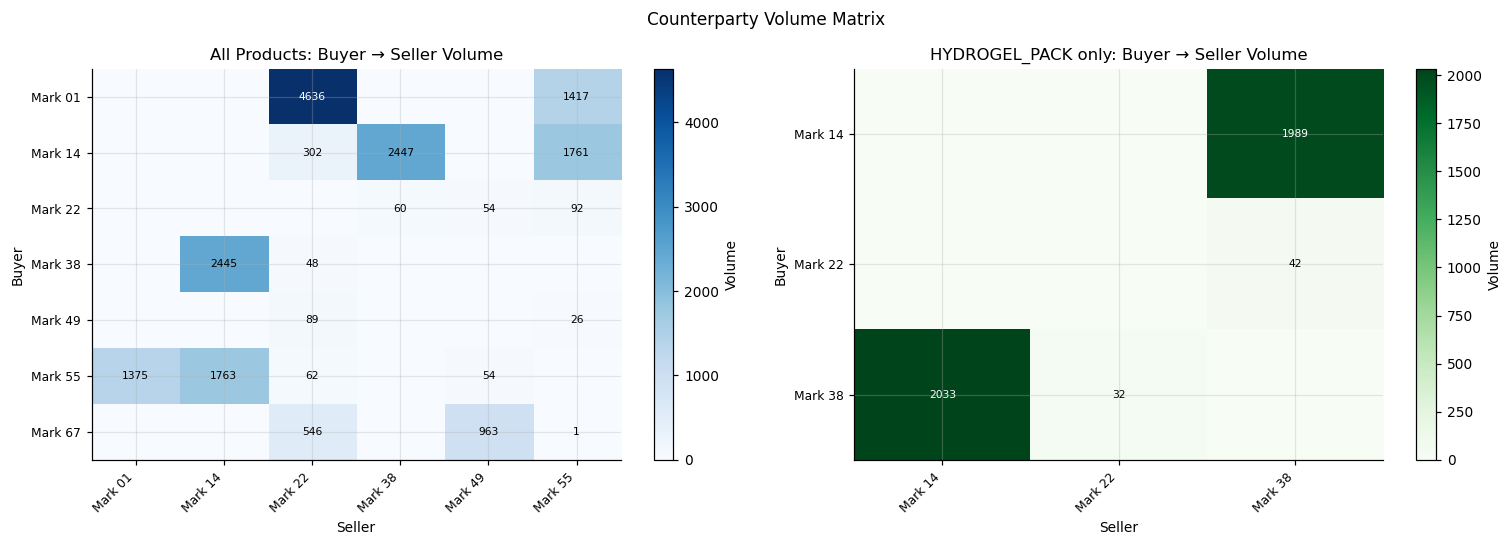

In [7]:
# Counterparty matrix: buyer → seller, color = total volume
cp_all = trades.groupby(['buyer', 'seller'])['quantity'].sum().unstack(fill_value=0)
cp = cp_all.loc[
    cp_all.index.isin(TRADERS),
    [c for c in TRADERS if c in cp_all.columns]
]

# Also show by product (top 3 product pairs)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Overall heatmap
ax = axes[0]
im = ax.imshow(cp.values, cmap='Blues', aspect='auto')
ax.set_xticks(range(len(cp.columns)))
ax.set_xticklabels(cp.columns, rotation=45, ha='right', fontsize=8)
ax.set_yticks(range(len(cp.index)))
ax.set_yticklabels(cp.index, fontsize=8)
plt.colorbar(im, ax=ax, label='Volume')
for i in range(len(cp.index)):
    for j in range(len(cp.columns)):
        v = int(cp.values[i, j])
        if v > 0:
            ax.text(j, i, str(v), ha='center', va='center', fontsize=7,
                    color='white' if v > cp.values.max() * 0.55 else 'black')
ax.set_title('All Products: Buyer → Seller Volume')
ax.set_ylabel('Buyer')
ax.set_xlabel('Seller')

# HYDRO only
ax2 = axes[1]
cp_hg = trades[trades['symbol'] == HYDRO].groupby(['buyer', 'seller'])['quantity'].sum().unstack(fill_value=0)
cp_hg = cp_hg.loc[
    [r for r in TRADERS if r in cp_hg.index],
    [c for c in TRADERS if c in cp_hg.columns]
]
if len(cp_hg) > 0:
    im2 = ax2.imshow(cp_hg.values, cmap='Greens', aspect='auto')
    ax2.set_xticks(range(len(cp_hg.columns)))
    ax2.set_xticklabels(cp_hg.columns, rotation=45, ha='right', fontsize=8)
    ax2.set_yticks(range(len(cp_hg.index)))
    ax2.set_yticklabels(cp_hg.index, fontsize=8)
    plt.colorbar(im2, ax=ax2, label='Volume')
    for i in range(len(cp_hg.index)):
        for j in range(len(cp_hg.columns)):
            v = int(cp_hg.values[i, j])
            if v > 0:
                ax2.text(j, i, str(v), ha='center', va='center', fontsize=7,
                         color='white' if v > cp_hg.values.max() * 0.55 else 'black')
    ax2.set_title('HYDROGEL_PACK only: Buyer → Seller Volume')
    ax2.set_ylabel('Buyer')
    ax2.set_xlabel('Seller')

plt.suptitle('Counterparty Volume Matrix', fontsize=11)
plt.tight_layout()
plt.show()

In [8]:
# Build MtM PnL for every trader
# At each trade event: pos[product] updates, cash updates,
# PnL = cash + sum(pos[p] * current_mid[p])

idx_ts = mid_wide.index

def build_trader_pnl(trader_name):
    tevents = events[events['trader'] == trader_name].sort_values('global_ts')
    pos, cash = defaultdict(float), 0.0
    records = []

    for _, row in tevents.iterrows():
        pos[row['symbol']] += row['signed_qty']
        cash += row['cash_flow']
        ts = row['global_ts']

        i = max(0, idx_ts.searchsorted(ts, side='right') - 1)
        snap = mid_wide.iloc[i]
        pos_val = sum(
            pos[p] * snap[p] for p in pos
            if p in snap.index and not np.isnan(snap[p])
        )
        records.append({
            'global_ts': ts, 'pnl': cash + pos_val,
            'cash': cash, 'pos_value': pos_val,
            'symbol': row['symbol'], 'side': row['side'],
            'price': row['price'],
        })
    return pd.DataFrame(records)

def build_trader_positions(trader_name):
    '''Returns {product: DataFrame(global_ts, position)} for each product traded.'''
    tevents = events[events['trader'] == trader_name].sort_values('global_ts')
    result = {}
    for product in tevents['symbol'].unique():
        pev = tevents[tevents['symbol'] == product][['global_ts', 'signed_qty', 'side', 'price']].copy()
        pev['position'] = pev['signed_qty'].cumsum()
        result[product] = pev.reset_index(drop=True)
    return result

trader_pnls = {t: build_trader_pnl(t) for t in TRADERS}
trader_positions = {t: build_trader_positions(t) for t in TRADERS}

print('PnL built. Summary:')
for t in TRADERS:
    df = trader_pnls[t]
    if len(df):
        print(f'  {t:10s}  final_pnl={df["pnl"].iloc[-1]:+9.0f}  max={df["pnl"].max():+8.0f}  min={df["pnl"].min():+8.0f}')

PnL built. Summary:
  Mark 01     final_pnl=    -3714  max=  +13514  min=   -8932
  Mark 14     final_pnl=   +38594  max=  +46800  min=     +21
  Mark 22     final_pnl=   +21592  max=  +49376  min=  -21650
  Mark 38     final_pnl=   -32905  max=     -16  min=  -35859
  Mark 49     final_pnl=    +6704  max=  +27546  min=  -21477
  Mark 55     final_pnl=   -16304  max=   +1034  min=  -17773
  Mark 67     final_pnl=    -8765  max=  +33513  min=  -62455


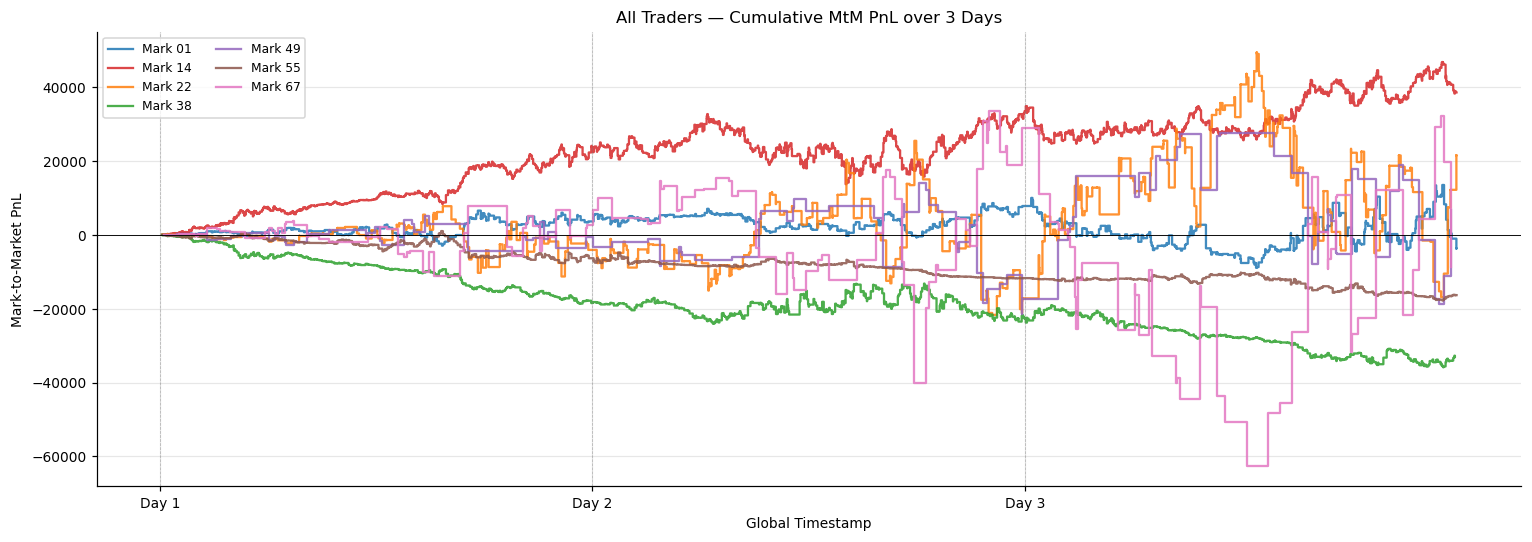

In [9]:
fig, ax = plt.subplots(figsize=(14, 5))

for trader in TRADERS:
    df = trader_pnls[trader]
    if len(df) == 0:
        continue
    ax.step(df['global_ts'], df['pnl'], where='post',
            label=trader, color=COLORS[trader], lw=1.5, alpha=0.85)

for ds in day_starts:
    ax.axvline(ds, color='gray', lw=0.5, ls='--', alpha=0.5)
ax.axhline(0, color='black', lw=0.6)
ax.set_xlabel('Global Timestamp')
ax.set_ylabel('Mark-to-Market PnL')
ax.set_title('All Traders — Cumulative MtM PnL over 3 Days')
ax.legend(loc='upper left', fontsize=8, ncol=2)
ax.set_xticks(day_starts)
ax.set_xticklabels([f'Day {d}' for d in DAYS])
plt.tight_layout()
plt.show()

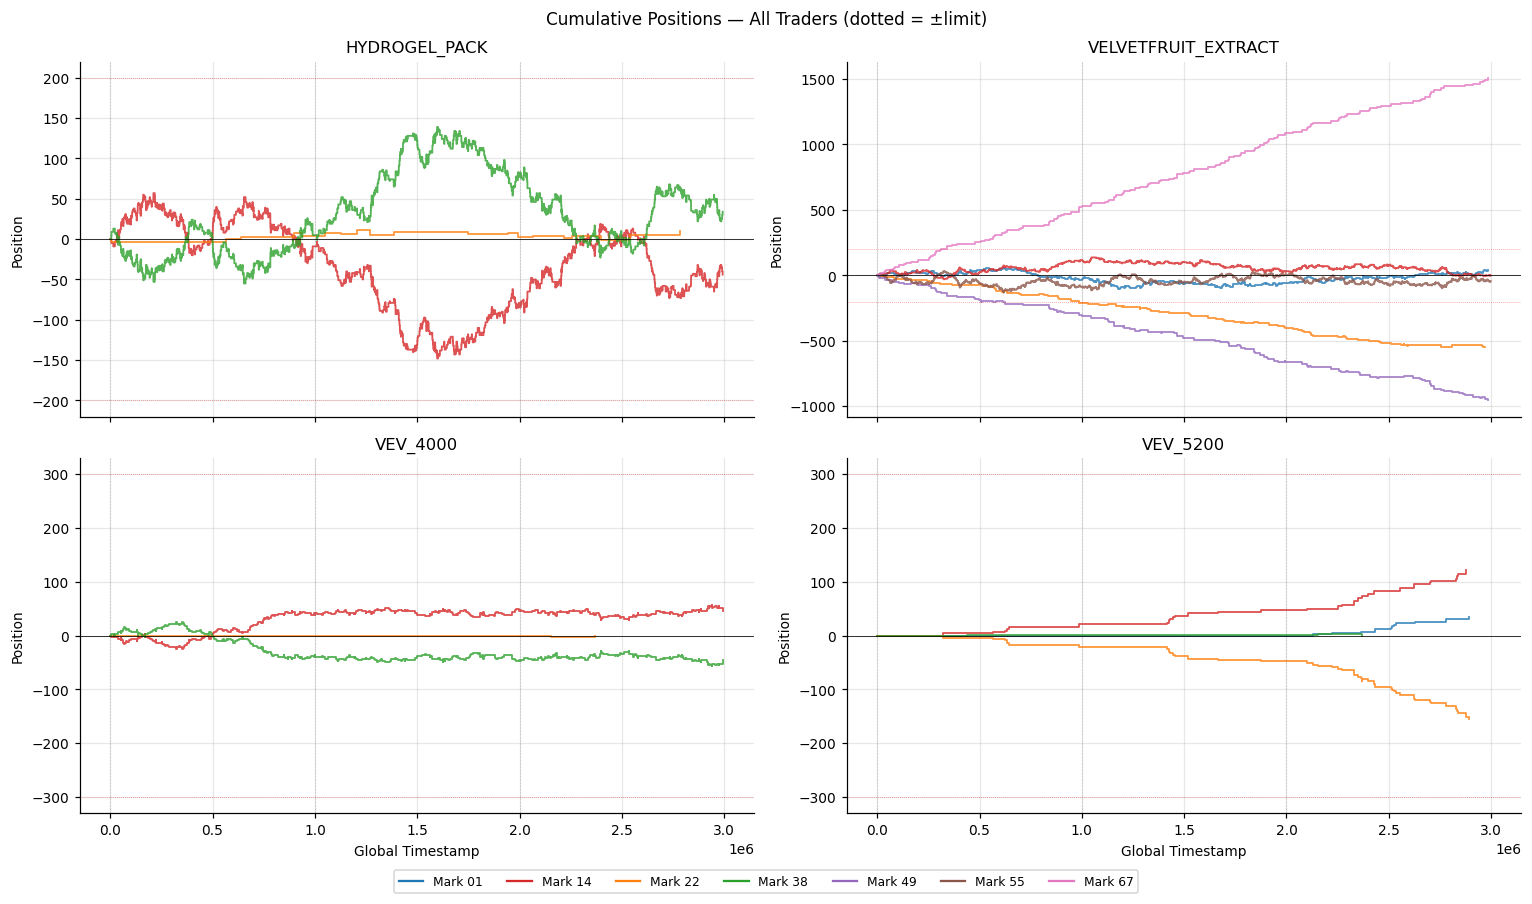

In [10]:
# Cumulative positions on 4 key products — all traders
key_products = [HYDRO, VELVET, 'VEV_4000', 'VEV_5200']
fig, axes = plt.subplots(2, 2, figsize=(14, 8), sharex=True)
axes = axes.flatten()

for ax, product in zip(axes, key_products):
    for trader in TRADERS:
        pos_dict = trader_positions.get(trader, {})
        if product not in pos_dict:
            continue
        pev = pos_dict[product]
        xs = np.concatenate([[0], pev['global_ts'].values])
        ys = np.concatenate([[0], pev['position'].values])
        ax.step(xs, ys, where='post', label=trader, color=COLORS[trader], lw=1.2, alpha=0.8)

    for ds in day_starts:
        ax.axvline(ds, color='gray', lw=0.4, ls='--', alpha=0.4)
    ax.axhline(0, color='black', lw=0.5)
    lim = LIMITS.get(product, 300)
    ax.axhline(lim,  color='red', lw=0.5, ls=':', alpha=0.5, label='limit')
    ax.axhline(-lim, color='red', lw=0.5, ls=':', alpha=0.5)
    ax.set_title(product)
    ax.set_ylabel('Position')

handles = [plt.Line2D([0], [0], color=COLORS[t], label=t, lw=1.5) for t in TRADERS]
fig.legend(handles=handles, loc='lower center', ncol=7, fontsize=8, bbox_to_anchor=(0.5, -0.03))
for ax in axes[-2:]:
    ax.set_xlabel('Global Timestamp')
plt.suptitle('Cumulative Positions — All Traders (dotted = ±limit)', fontsize=11)
plt.tight_layout()
plt.show()

In [11]:
# Summary stats per trader
rows = []
for trader in TRADERS:
    df   = trader_pnls[trader]
    tevs = events[events['trader'] == trader]
    rows.append({
        'Trader'      : trader,
        'Final PnL'   : round(df['pnl'].iloc[-1]) if len(df) else 0,
        'Max PnL'     : round(df['pnl'].max())     if len(df) else 0,
        'Min PnL'     : round(df['pnl'].min())     if len(df) else 0,
        '# Trades'    : len(tevs),
        'Volume'      : int(tevs['quantity'].sum()),
        '# Products'  : tevs['symbol'].nunique(),
        'Buy%'        : round(100 * (tevs['side'] == 'BUY').mean(), 1),
    })

summary = pd.DataFrame(rows).set_index('Trader').sort_values('Final PnL', ascending=False)
display(summary.style
    .background_gradient(cmap='RdYlGn', subset=['Final PnL'])
    .background_gradient(cmap='Blues',  subset=['Volume'])
    .format({
        'Final PnL': '{:+,.0f}', 'Max PnL': '{:+,.0f}', 'Min PnL': '{:+,.0f}',
        'Volume': '{:,}', '# Trades': '{:,}', 'Buy%': '{:.1f}%',
    }))

,Final PnL,Max PnL,Min PnL,# Trades,Volume,# Products,Buy%
Trader,,,,,,,
Mark 14,"+38,594","+46,800",+21,"2,172","8,718",7,51.9%
Mark 22,"+21,592","+49,376","-21,650","1,584","5,889",12,2.7%
Mark 49,"+6,704","+27,546","-21,477",122,"1,186",1,13.9%
Mark 01,"-3,714","+13,514","-8,932","1,843","7,428",7,86.8%
Mark 67,"-8,765","+33,513","-62,455",165,"1,510",1,100.0%
Mark 55,"-16,304","+1,034","-17,773","1,198","6,551",1,49.9%
Mark 38,"-32,905",-16,"-35,859","1,478","5,000",7,49.6%


## 3. Deep Dive — Mark 14

Mark 14 is the highest-volume trader. Heavy activity on HYDROGEL_PACK and VEV_4000.  
Primary counterparty: Mark 38 (they trade directly against each other constantly).

Key questions:
- Are they market-making (trade price ≈ spread inside mid) or directional?
- Does their position accumulate or oscillate (MM) around zero?

In [12]:
def plot_mid_bg(ax, product, downsample=50):
    '''Draw mid-price as grey background line on ax.'''
    if product not in mid_wide.columns:
        return
    s = mid_wide[product].dropna().iloc[::downsample]
    ax.plot(s.index, s.values, color='steelblue', lw=0.6, alpha=0.5, label='Mid')
    for ds in day_starts:
        ax.axvline(ds, color='gray', lw=0.4, ls='--', alpha=0.3)

def plot_trade_events(ax, trader, product, buy_color='green', sell_color='red', size=30):
    '''Scatter buy/sell markers at trade price.'''
    tevs = events[(events['trader'] == trader) & (events['symbol'] == product)]
    buys  = tevs[tevs['side'] == 'BUY']
    sells = tevs[tevs['side'] == 'SELL']
    if len(buys):
        ax.scatter(buys['global_ts'],  buys['price'],  marker='^', s=size,
                   color=buy_color,  alpha=0.75, zorder=5, label=f'{trader} BUY ({len(buys)})')
    if len(sells):
        ax.scatter(sells['global_ts'], sells['price'], marker='v', s=size,
                   color=sell_color, alpha=0.75, zorder=5, label=f'{trader} SELL ({len(sells)})')
    return len(buys), len(sells)

def price_improvement_vs_mid(trader_name):
    '''For each trade: how far was trade price from mid at that time?
       BUY:  mid - trade_price  (positive = bought below mid, good for taker)
       SELL: trade_price - mid  (positive = sold above mid, good for taker)
    '''
    tevs = events[events['trader'] == trader_name].copy()
    improvements = []
    for _, row in tevs.iterrows():
        if row['symbol'] not in mid_wide.columns:
            continue
        i = max(0, idx_ts.searchsorted(row['global_ts'], side='right') - 1)
        mid = mid_wide[row['symbol']].iloc[i]
        if pd.isna(mid):
            continue
        diff = (mid - row['price']) if row['side'] == 'BUY' else (row['price'] - mid)
        improvements.append({'symbol': row['symbol'], 'side': row['side'], 'improvement': diff})
    return pd.DataFrame(improvements)

print('Helper functions defined.')

Helper functions defined.


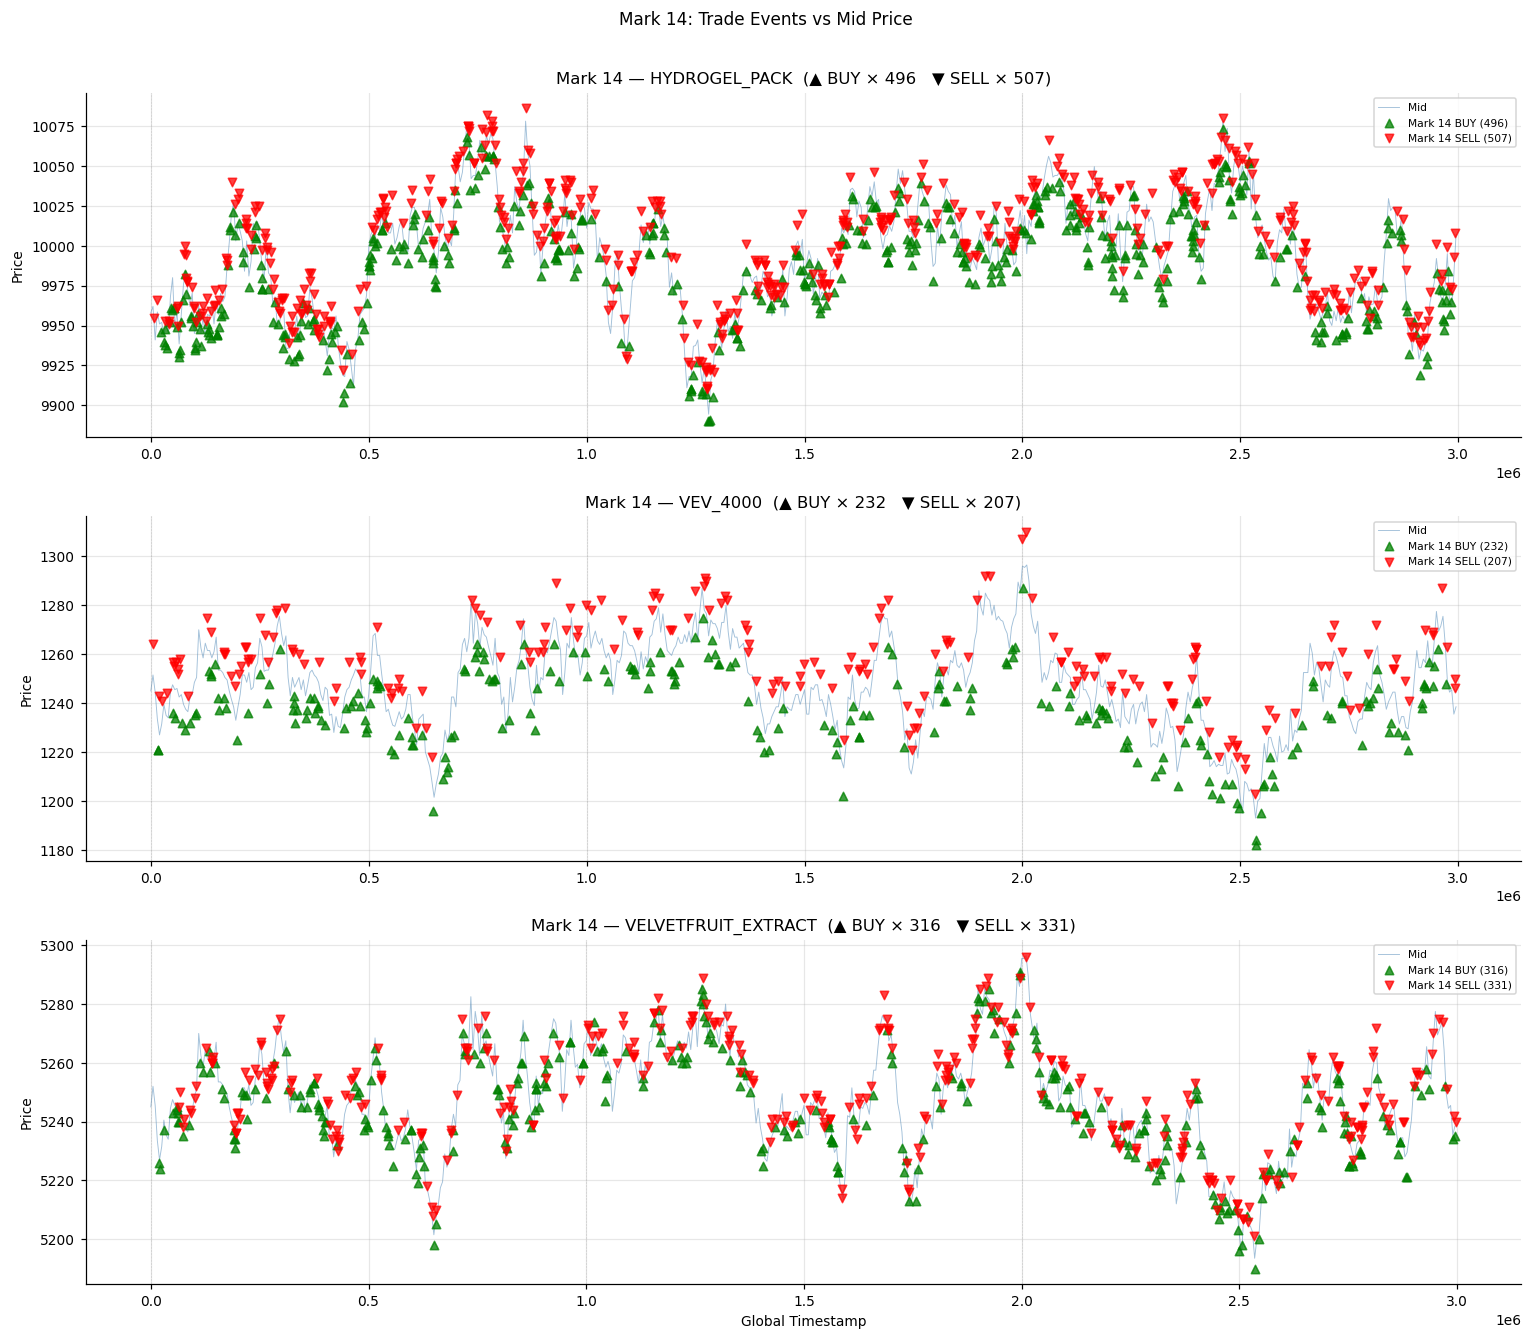

In [13]:
# Mark 14 trade event overlay on key products
m14_products = [HYDRO, 'VEV_4000', VELVET]
fig, axes = plt.subplots(len(m14_products), 1, figsize=(14, 4 * len(m14_products)))

for ax, product in zip(axes, m14_products):
    plot_mid_bg(ax, product)
    nb, ns = plot_trade_events(ax, 'Mark 14', product)
    ax.set_title(f'Mark 14 — {product}  (▲ BUY × {nb}   ▼ SELL × {ns})')
    ax.set_ylabel('Price')
    ax.legend(fontsize=7, loc='upper right')

axes[-1].set_xlabel('Global Timestamp')
plt.suptitle('Mark 14: Trade Events vs Mid Price', fontsize=11, y=1.01)
plt.tight_layout()
plt.show()

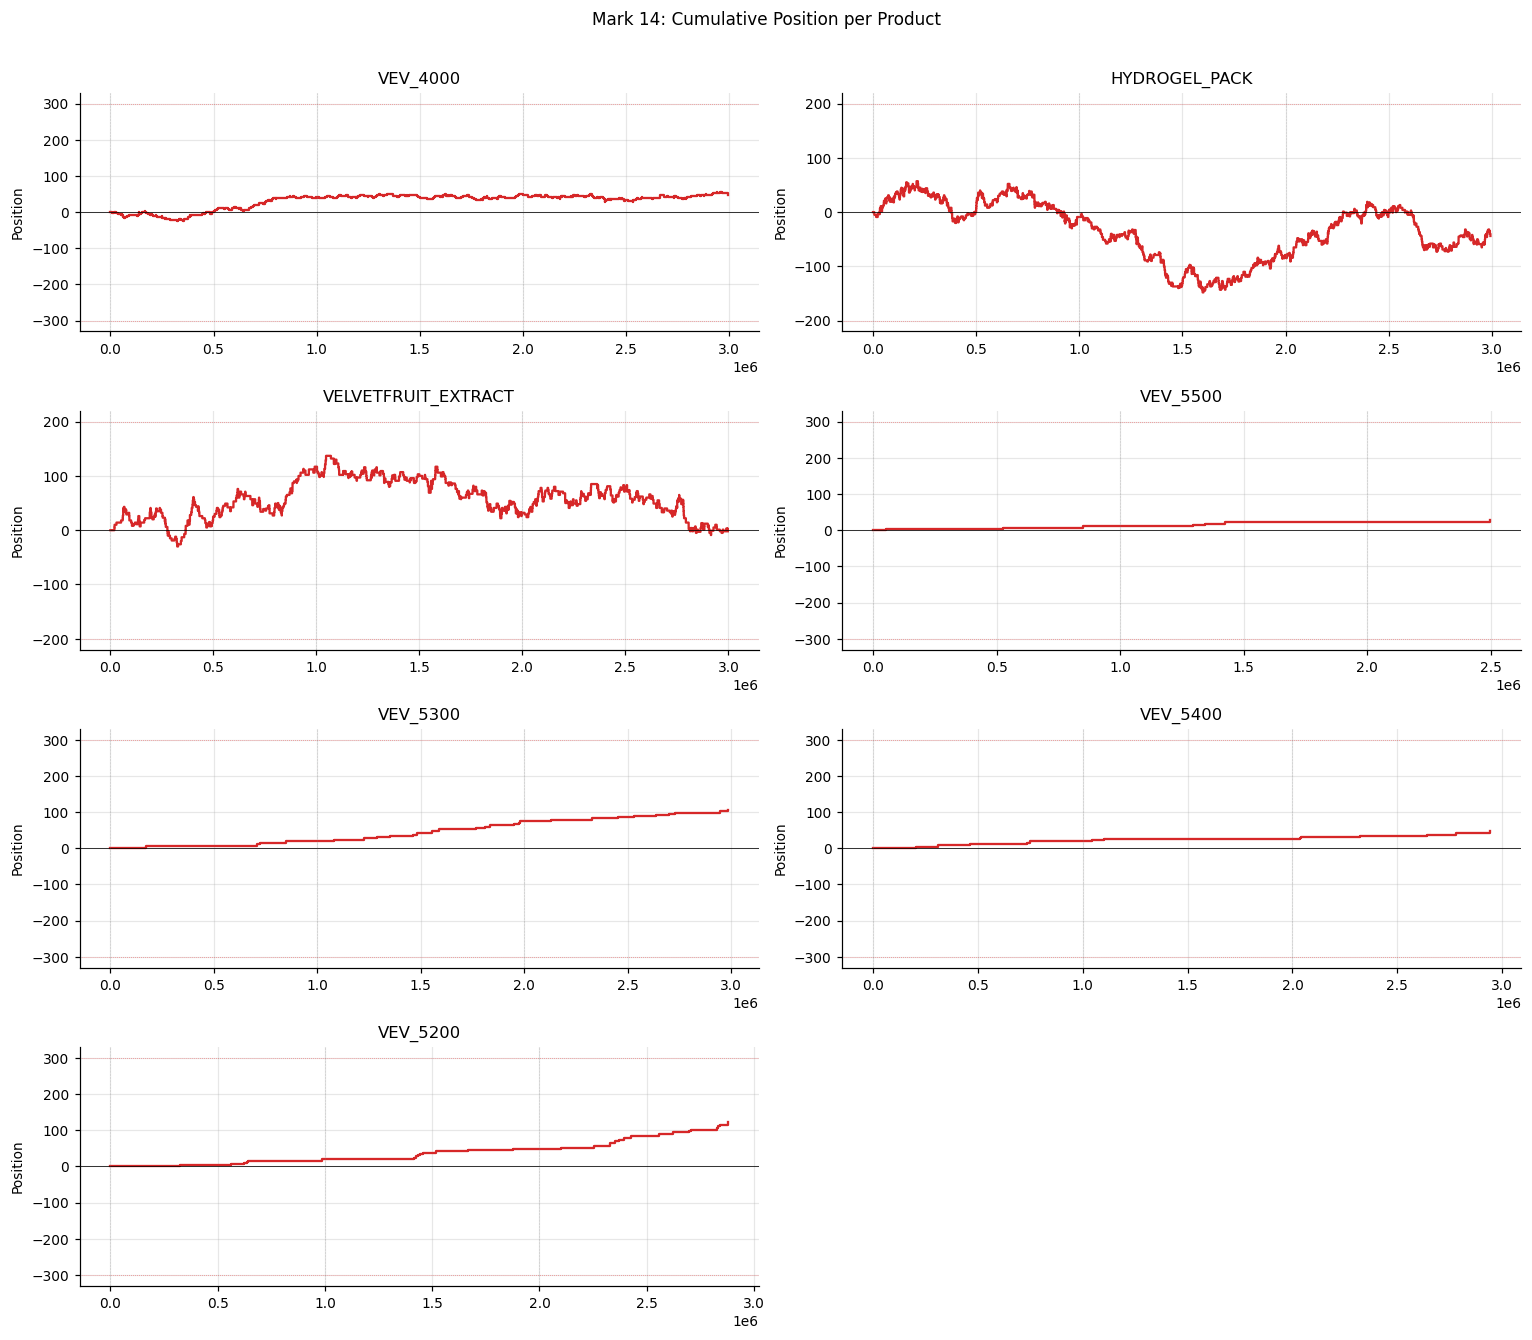

In [14]:
# Mark 14 cumulative position on all products they trade
m14_pos = trader_positions['Mark 14']
n_prods = len(m14_pos)
fig, axes = plt.subplots(max(1, (n_prods + 1) // 2), 2, figsize=(14, 3 * max(1, (n_prods + 1) // 2)))
axes = axes.flatten()

for i, (product, pev) in enumerate(m14_pos.items()):
    ax = axes[i]
    xs = np.concatenate([[0], pev['global_ts'].values])
    ys = np.concatenate([[0], pev['position'].values])
    ax.step(xs, ys, where='post', color=COLORS['Mark 14'], lw=1.5)
    ax.axhline(0, color='black', lw=0.5)
    lim = LIMITS.get(product, 300)
    ax.axhline(lim,  color='red', lw=0.5, ls=':', alpha=0.5)
    ax.axhline(-lim, color='red', lw=0.5, ls=':', alpha=0.5)
    for ds in day_starts:
        ax.axvline(ds, color='gray', lw=0.4, ls='--', alpha=0.3)
    ax.set_title(product)
    ax.set_ylabel('Position')

for ax in axes[n_prods:]:
    ax.set_visible(False)

plt.suptitle('Mark 14: Cumulative Position per Product', fontsize=11, y=1.01)
plt.tight_layout()
plt.show()

Mark 14 — Price Improvement vs Mid  (positive = traded on favorable side of spread)
  If mostly NEGATIVE → Mark 14 is a taker (pays spread, likely informed/directional)
  If mostly POSITIVE → Mark 14 is a maker (receives spread, market-making)



mean  median    std  count
symbol              side                              
HYDROGEL_PACK       BUY    7.981     8.0  0.288    496
                    SELL   7.941     8.0  0.445    507
VELVETFRUIT_EXTRACT BUY    2.430     2.5  0.326    316
                    SELL   2.462     2.5  0.208    331
VEV_4000            BUY   10.466    10.5  0.428    232
                    SELL  10.374    10.5  0.716    207
VEV_5200            BUY    1.000     1.0  0.000     33
VEV_5300            BUY    0.750     1.0  0.286     30
VEV_5400            BUY    0.462     0.5  0.139     13
VEV_5500            BUY    0.500     0.5  0.000      7

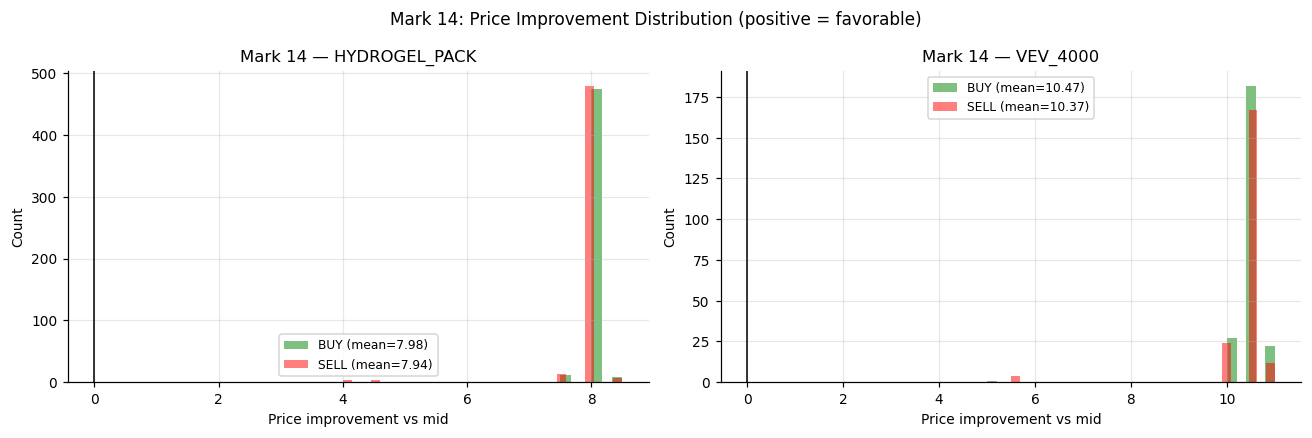

In [15]:
# Price improvement: positive = traded favorably vs mid (MM collects spread, taker pays it)
pi14 = price_improvement_vs_mid('Mark 14')
pi14_agg = pi14.groupby(['symbol', 'side'])['improvement'].agg(['mean', 'median', 'std', 'count']).round(3)
print('Mark 14 — Price Improvement vs Mid  (positive = traded on favorable side of spread)')
print('  If mostly NEGATIVE → Mark 14 is a taker (pays spread, likely informed/directional)')
print('  If mostly POSITIVE → Mark 14 is a maker (receives spread, market-making)')
print()
display(pi14_agg)

# Histogram for HYDRO
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, product in zip(axes, [HYDRO, 'VEV_4000']):
    sub = pi14[pi14['symbol'] == product]
    if len(sub) == 0:
        continue
    for side, color in [('BUY', 'green'), ('SELL', 'red')]:
        vals = sub[sub['side'] == side]['improvement']
        if len(vals):
            ax.hist(vals, bins=30, color=color, alpha=0.5, label=f'{side} (mean={vals.mean():.2f})')
    ax.axvline(0, color='black', lw=1)
    ax.set_xlabel('Price improvement vs mid')
    ax.set_ylabel('Count')
    ax.set_title(f'Mark 14 — {product}')
    ax.legend(fontsize=8)

plt.suptitle('Mark 14: Price Improvement Distribution (positive = favorable)', fontsize=11)
plt.tight_layout()
plt.show()

## 4. Deep Dive — Mark 38

Mark 38's primary counterparty on HYDRO and VEV_4000 is Mark 14.  
We compare their positions side-by-side to understand who is making vs taking.

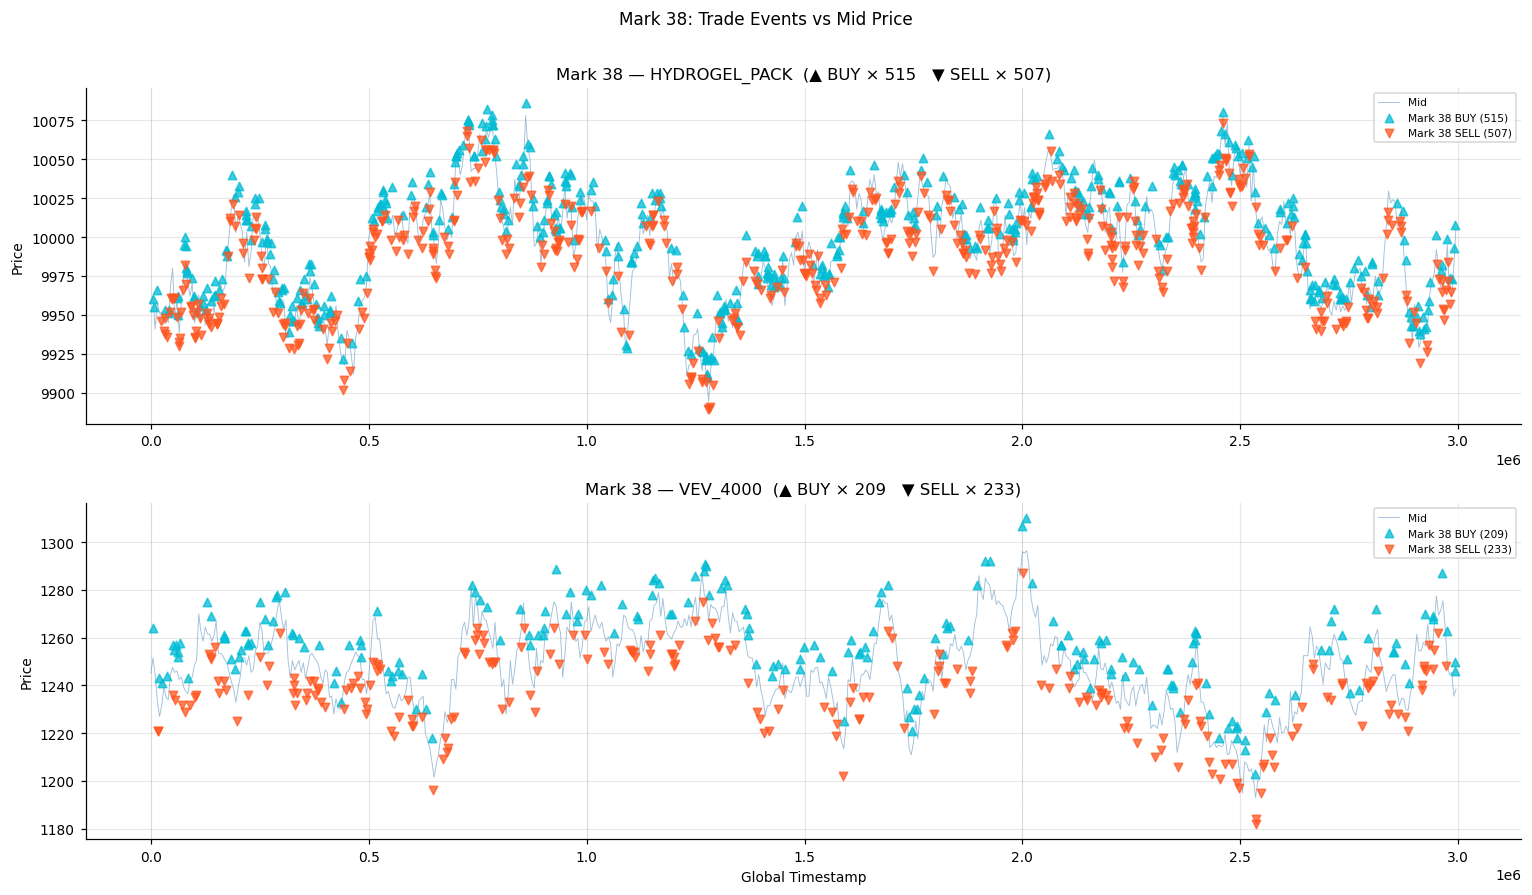

In [16]:
m38_products = [HYDRO, 'VEV_4000']
fig, axes = plt.subplots(len(m38_products), 1, figsize=(14, 4 * len(m38_products)))

for ax, product in zip(axes, m38_products):
    plot_mid_bg(ax, product)
    nb, ns = plot_trade_events(ax, 'Mark 38', product, '#00bcd4', '#ff5722')
    ax.set_title(f'Mark 38 — {product}  (▲ BUY × {nb}   ▼ SELL × {ns})')
    ax.set_ylabel('Price')
    ax.legend(fontsize=7, loc='upper right')

axes[-1].set_xlabel('Global Timestamp')
plt.suptitle('Mark 38: Trade Events vs Mid Price', fontsize=11, y=1.01)
plt.tight_layout()
plt.show()

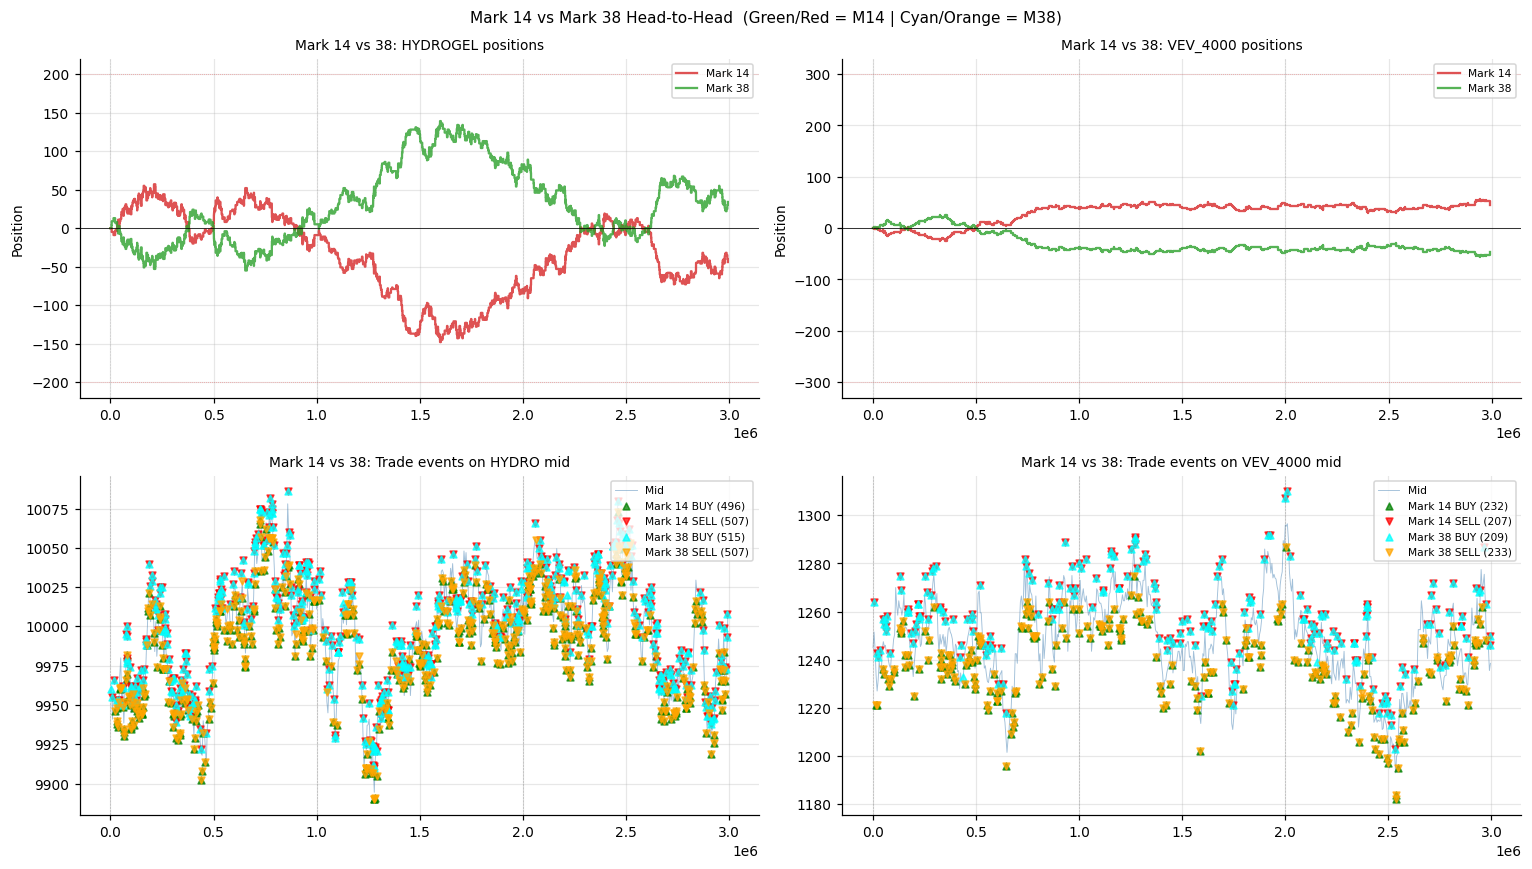

In [17]:
# Mark 14 vs Mark 38 overlaid — same axes, do they mirror each other?
fig, axes = plt.subplots(2, 2, figsize=(14, 8))
axes = axes.flatten()

configs = [
    (HYDRO,     'Mark 14 vs 38: HYDROGEL positions'),
    ('VEV_4000', 'Mark 14 vs 38: VEV_4000 positions'),
    (HYDRO,     'Mark 14 vs 38: Trade events on HYDRO mid'),
    ('VEV_4000', 'Mark 14 vs 38: Trade events on VEV_4000 mid'),
]

for ax_i, (product, title) in enumerate(configs):
    ax = axes[ax_i]
    if ax_i < 2:
        # Position plots
        for trader in ['Mark 14', 'Mark 38']:
            pos_dict = trader_positions.get(trader, {})
            if product not in pos_dict:
                continue
            pev = pos_dict[product]
            xs = np.concatenate([[0], pev['global_ts'].values])
            ys = np.concatenate([[0], pev['position'].values])
            ax.step(xs, ys, where='post', label=trader, color=COLORS[trader], lw=1.5, alpha=0.8)
        ax.axhline(0, color='black', lw=0.5)
        lim = LIMITS.get(product, 300)
        ax.axhline(lim,  color='red', lw=0.5, ls=':', alpha=0.4)
        ax.axhline(-lim, color='red', lw=0.5, ls=':', alpha=0.4)
        ax.set_ylabel('Position')
    else:
        # Trade event overlays
        plot_mid_bg(ax, product)
        plot_trade_events(ax, 'Mark 14', product, 'green', 'red', size=20)
        plot_trade_events(ax, 'Mark 38', product, 'cyan',  'orange', size=20)

    for ds in day_starts:
        ax.axvline(ds, color='gray', lw=0.4, ls='--', alpha=0.3)
    ax.set_title(title, fontsize=9)
    ax.legend(fontsize=7, loc='upper right')

plt.suptitle('Mark 14 vs Mark 38 Head-to-Head  (Green/Red = M14 | Cyan/Orange = M38)', fontsize=10)
plt.tight_layout()
plt.show()

In [18]:
pi38 = price_improvement_vs_mid('Mark 38')
print('Mark 38 — Price Improvement vs Mid')
display(pi38.groupby(['symbol', 'side'])['improvement'].agg(['mean', 'median', 'std', 'count']).round(3))

print()
# Compare M14 vs M38 on HYDRO
for product in [HYDRO, 'VEV_4000']:
    sub14 = pi14[pi14['symbol'] == product]['improvement']
    sub38 = pi38[pi38['symbol'] == product]['improvement']
    if len(sub14) and len(sub38):
        print(f'{product}: M14 avg_improvement={sub14.mean():.3f}  M38 avg_improvement={sub38.mean():.3f}')

Mark 38 — Price Improvement vs Mid


mean  median    std  count
symbol        side                              
HYDROGEL_PACK BUY   -7.873   -8.00  0.699    515
              SELL  -7.896   -8.00  0.635    507
VEV_4000      BUY  -10.323  -10.50  0.885    209
              SELL -10.444  -10.50  0.536    233
VEV_4500      BUY   -3.500   -3.50  0.000      2
              SELL  -4.000   -4.00    NaN      1
VEV_5000      BUY   -1.000   -1.00  0.000      2
              SELL  -1.500   -1.50    NaN      1
VEV_5100      BUY   -0.750   -0.75  0.354      2
              SELL  -1.500   -1.50    NaN      1
VEV_5200      BUY   -0.500   -0.50  0.000      2
              SELL  -1.000   -1.00    NaN      1
VEV_5300      BUY   -0.500   -0.50    NaN      1
              SELL  -0.500   -0.50    NaN      1


HYDROGEL_PACK: M14 avg_improvement=7.961  M38 avg_improvement=-7.885
VEV_4000: M14 avg_improvement=10.423  M38 avg_improvement=-10.387


## 5. Deep Dive — Mark 67

**Key finding so far**: Mark 67 is a **pure buyer** of VELVETFRUIT_EXTRACT across all 3 days.  
They never appear as a seller. This is a strong signal of a directional/informed trader.

We test whether their buy timing is predictive of subsequent VELVET price moves.

Mark 67: 165 trade events
          volume  trades   avg_qty
day side                          
1   BUY      519      58  8.948276
2   BUY      567      61  9.295082
3   BUY      424      46  9.217391

Counterparties traded against:
seller
Mark 49    89
Mark 22    75
Mark 55     1
Name: count, dtype: int64


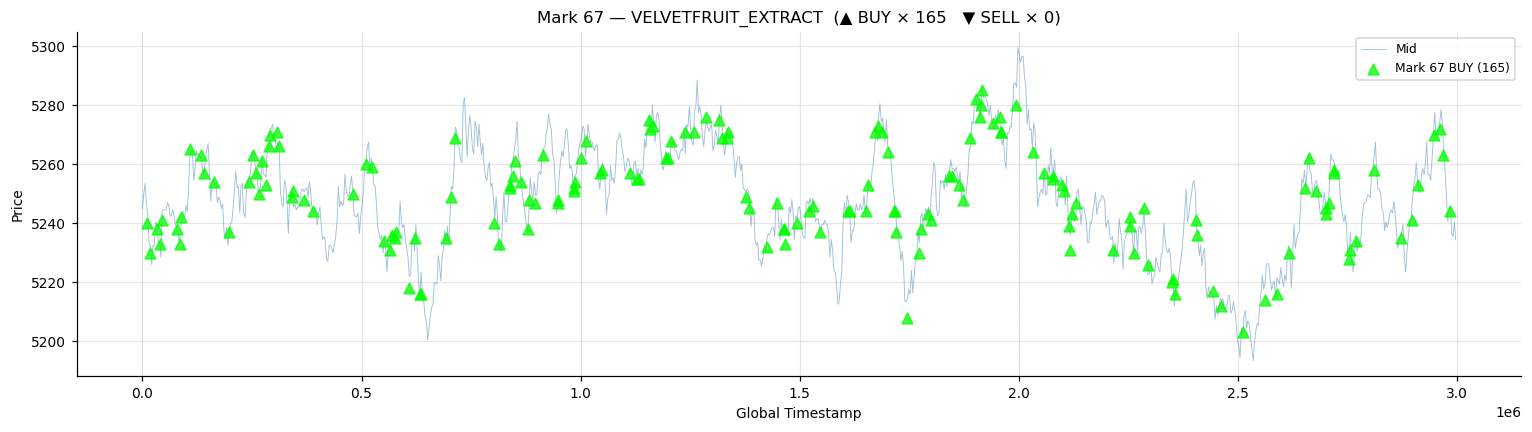

In [19]:
m67_events = events[events['trader'] == 'Mark 67']
print(f'Mark 67: {len(m67_events)} trade events')
print(m67_events.groupby(['day', 'side'])['quantity'].agg(['sum', 'count', 'mean']).rename(
    columns={'sum': 'volume', 'count': 'trades', 'mean': 'avg_qty'}))

print(f'\nCounterparties traded against:')
cp67 = trades[trades['buyer'] == 'Mark 67']['seller'].value_counts()
print(cp67)

fig, ax = plt.subplots(figsize=(14, 4))
plot_mid_bg(ax, VELVET, downsample=30)
nb, ns = plot_trade_events(ax, 'Mark 67', VELVET, 'lime', 'crimson', size=50)
ax.set_title(f'Mark 67 — VELVETFRUIT_EXTRACT  (▲ BUY × {nb}   ▼ SELL × {ns})')
ax.set_xlabel('Global Timestamp')
ax.set_ylabel('Price')
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

Mark 67 — Average forward return of VELVET after each trade:
  (positive = VELVET went UP after their trade — confirming informed buyer)

     50 ticks:  BUY→ +1.918   SELL→ +nan  (n=165/0)
    200 ticks:  BUY→ +1.961   SELL→ +nan  (n=165/0)
    500 ticks:  BUY→ +1.185   SELL→ +nan  (n=165/0)
   1000 ticks:  BUY→ -0.882   SELL→ +nan  (n=165/0)
   2000 ticks:  BUY→ +0.473   SELL→ +nan  (n=165/0)
   5000 ticks:  BUY→ -4.494   SELL→ +nan  (n=165/0)


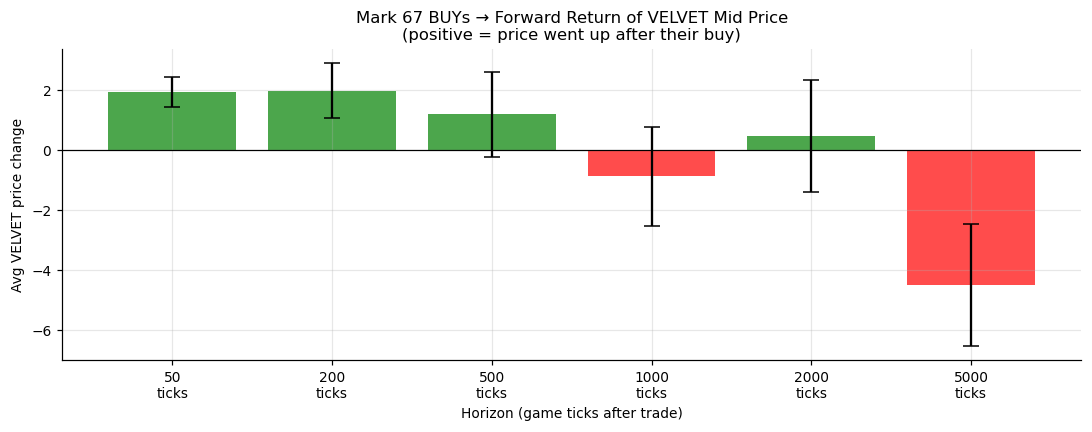

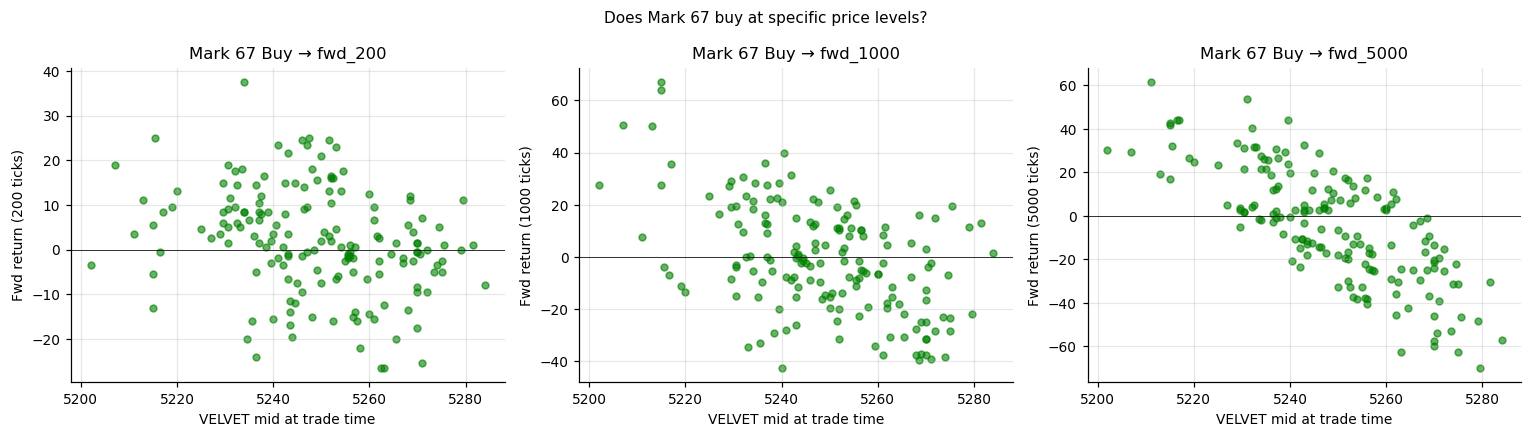

In [20]:
# Forward return analysis: after Mark 67 buys, does VELVET price go up?
# (positive mean forward return after buys = informed trader)

if VELVET not in mid_wide.columns:
    print('No VELVET mid price data')
else:
    vel_mid = mid_wide[VELVET].dropna()
    vel_ts  = vel_mid.index

    FORWARD_TICKS = [50, 200, 500, 1000, 2000, 5000]  # in timestamp units × 100
    # (each game tick = 100 timestamp units; 50 ticks ≈ short term, 5000 ≈ ~8% of a day)

    m67_vf = m67_events[m67_events['symbol'] == VELVET].copy()

    fwd_records = []
    for _, row in m67_vf.iterrows():
        ts = row['global_ts']
        i_now = max(0, vel_ts.searchsorted(ts, side='right') - 1)
        mid_now = vel_mid.iloc[i_now]

        rec = {
            'ts': ts, 'side': row['side'], 'day': row['day'],
            'price': row['price'], 'mid_now': mid_now,
        }
        for n in FORWARD_TICKS:
            target_ts = ts + n * 100
            i_fwd = min(vel_ts.searchsorted(target_ts, side='right') - 1, len(vel_ts) - 1)
            rec[f'fwd_{n}'] = vel_mid.iloc[i_fwd] - mid_now
        fwd_records.append(rec)

    fwd_df = pd.DataFrame(fwd_records)

    print('Mark 67 — Average forward return of VELVET after each trade:')
    print('  (positive = VELVET went UP after their trade — confirming informed buyer)')
    print()
    buys  = fwd_df[fwd_df['side'] == 'BUY']
    sells = fwd_df[fwd_df['side'] == 'SELL']
    for n in FORWARD_TICKS:
        b_mean = buys[f'fwd_{n}'].mean()  if len(buys)  else float('nan')
        s_mean = sells[f'fwd_{n}'].mean() if len(sells) else float('nan')
        print(f'  {n:5d} ticks:  BUY→ {b_mean:+.3f}   SELL→ {s_mean:+.3f}  (n={len(buys)}/{len(sells)})')

    # Bar chart: forward return by horizon
    fig, ax = plt.subplots(figsize=(10, 4))
    means = [buys[f'fwd_{n}'].mean() for n in FORWARD_TICKS]
    sems  = [buys[f'fwd_{n}'].sem()  for n in FORWARD_TICKS]
    colors = ['green' if m > 0 else 'red' for m in means]
    ax.bar(range(len(FORWARD_TICKS)), means, yerr=sems, color=colors, alpha=0.7, capsize=5)
    ax.set_xticks(range(len(FORWARD_TICKS)))
    ax.set_xticklabels([f'{n}\nticks' for n in FORWARD_TICKS])
    ax.set_xlabel('Horizon (game ticks after trade)')
    ax.set_ylabel('Avg VELVET price change')
    ax.set_title('Mark 67 BUYs → Forward Return of VELVET Mid Price\n(positive = price went up after their buy)')
    ax.axhline(0, color='black', lw=0.8)
    plt.tight_layout()
    plt.show()

    # Scatter: trade price vs subsequent return
    fig, axes = plt.subplots(1, 3, figsize=(14, 4))
    for ax, n in zip(axes, [200, 1000, 5000]):
        ax.scatter(buys['mid_now'], buys[f'fwd_{n}'], s=20, alpha=0.6, color='green')
        ax.axhline(0, color='black', lw=0.5)
        ax.set_xlabel('VELVET mid at trade time')
        ax.set_ylabel(f'Fwd return ({n} ticks)')
        ax.set_title(f'Mark 67 Buy → fwd_{n}')
    plt.suptitle('Does Mark 67 buy at specific price levels?', fontsize=10)
    plt.tight_layout()
    plt.show()

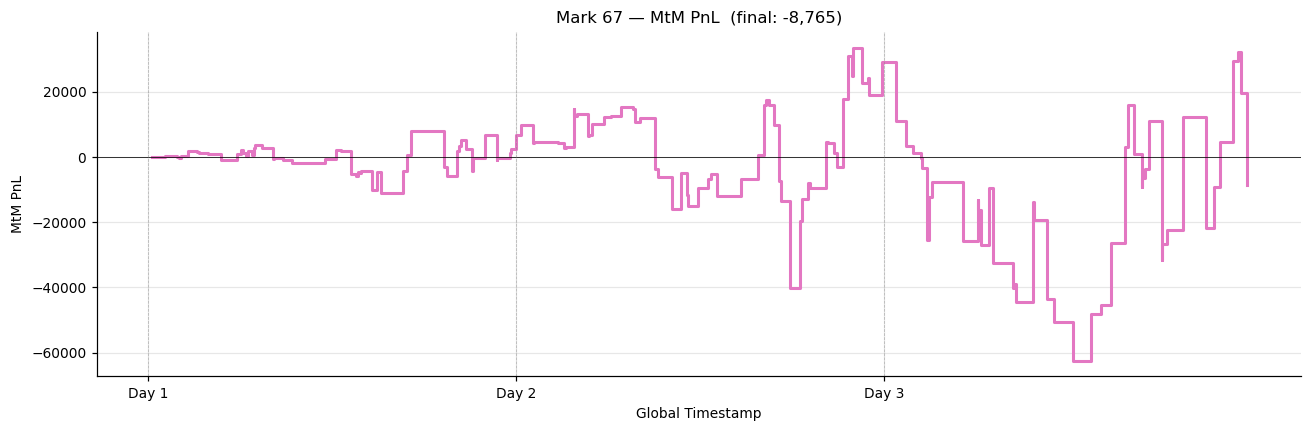

In [21]:
# Mark 67 PnL curve
df67 = trader_pnls['Mark 67']
fig, ax = plt.subplots(figsize=(12, 4))
if len(df67):
    ax.step(df67['global_ts'], df67['pnl'], where='post', color=COLORS['Mark 67'], lw=2)
    ax.axhline(0, color='black', lw=0.5)
    for ds in day_starts:
        ax.axvline(ds, color='gray', lw=0.5, ls='--', alpha=0.5)
    ax.set_xlabel('Global Timestamp')
    ax.set_ylabel('MtM PnL')
    ax.set_title(f'Mark 67 — MtM PnL  (final: {df67["pnl"].iloc[-1]:+,.0f})')
    ax.set_xticks(day_starts)
    ax.set_xticklabels([f'Day {d}' for d in DAYS])
plt.tight_layout()
plt.show()

## 6. Options Price Series Analysis

Before running a mean-reversion strategy, we need to understand the statistical properties  
of each option's price series. Key challenges:

- Options decay in value as TTE shrinks (4→1 days) — raw prices are non-stationary by construction
- We compute **BS residuals** (market price − theoretical BS price) which should be stationary
- We then run ADF, ACF, half-life on the residuals

In [22]:
# Compute BS fair value and residual for each option at each timestamp
# Spot = VELVET mid price; TTE = 4 - (day-1) - ts/TPD days

if VELVET not in mid_wide.columns:
    print('No VELVET data — cannot compute BS fair')
else:
    # Build residual series: for each option, compute mid - BS(spot, K, TTE, sigma)
    # We downsample to every 100 ticks (every 10 seconds) for tractability
    SAMPLE_STEP = 100

    residuals = {}   # {option: Series(global_ts -> residual)}
    bs_fairs  = {}   # {option: Series(global_ts -> bs_fair)}

    all_ts = mid_wide.index[::SAMPLE_STEP]

    # Precompute spot and TTE at each sampled timestamp
    spots = mid_wide.loc[all_ts, VELVET].ffill().values

    # Day and within-day ts for each sampled global_ts
    days_arr = (all_ts // TPD).astype(int) + 1   # 1-indexed day
    ts_arr   = all_ts % TPD                        # within-day timestamp

    for strike in STRIKES:
        opt = f'VEV_{strike}'
        if opt not in mid_wide.columns:
            continue

        mids = mid_wide.loc[all_ts, opt].ffill().values
        fairs = np.zeros(len(all_ts))

        for j in range(len(all_ts)):
            spot = spots[j]
            d    = int(days_arr[j])
            ts_j = int(ts_arr[j])
            if np.isnan(spot) or spot <= 0:
                continue
            t_yr  = tte_years(d, ts_j)
            sigma = static_sigma(spot, strike)
            fairs[j] = bs_call(spot, strike, t_yr, sigma)

        fair_s = pd.Series(fairs, index=all_ts)
        mid_s  = pd.Series(mids,  index=all_ts)
        bs_fairs[opt]  = fair_s
        residuals[opt] = mid_s - fair_s

    print('BS residuals computed for all options.')
    print(f'Sample step: every {SAMPLE_STEP} ticks ({SAMPLE_STEP * 100 / 1000:.0f}s) | '
          f'{len(all_ts):,} samples per series')

    # Show residual stats
    resid_stats = []
    for opt, r in residuals.items():
        resid_stats.append({
            'Option': opt,
            'Resid Mean': round(r.mean(), 3),
            'Resid Std' : round(r.std(),  3),
            'Resid Min' : round(r.min(),  3),
            'Resid Max' : round(r.max(),  3),
        })
    display(pd.DataFrame(resid_stats).set_index('Option'))

BS residuals computed for all options.
Sample step: every 100 ticks (10s) | 300 samples per series


,Resid Mean,Resid Std,Resid Min,Resid Max
Option,,,,
VEV_4000,0.043,0.910,-7.000,6.500
VEV_4500,0.013,0.804,-5.500,5.500
VEV_5000,3.061,1.133,-1.504,6.298
VEV_5100,9.388,1.754,4.416,14.792
VEV_5200,19.544,2.083,15.531,25.177
VEV_5300,20.143,1.969,15.987,26.664
VEV_5400,8.418,1.673,3.817,13.944
VEV_5500,4.110,1.682,0.496,7.445
VEV_6000,0.500,0.000,0.500,0.500


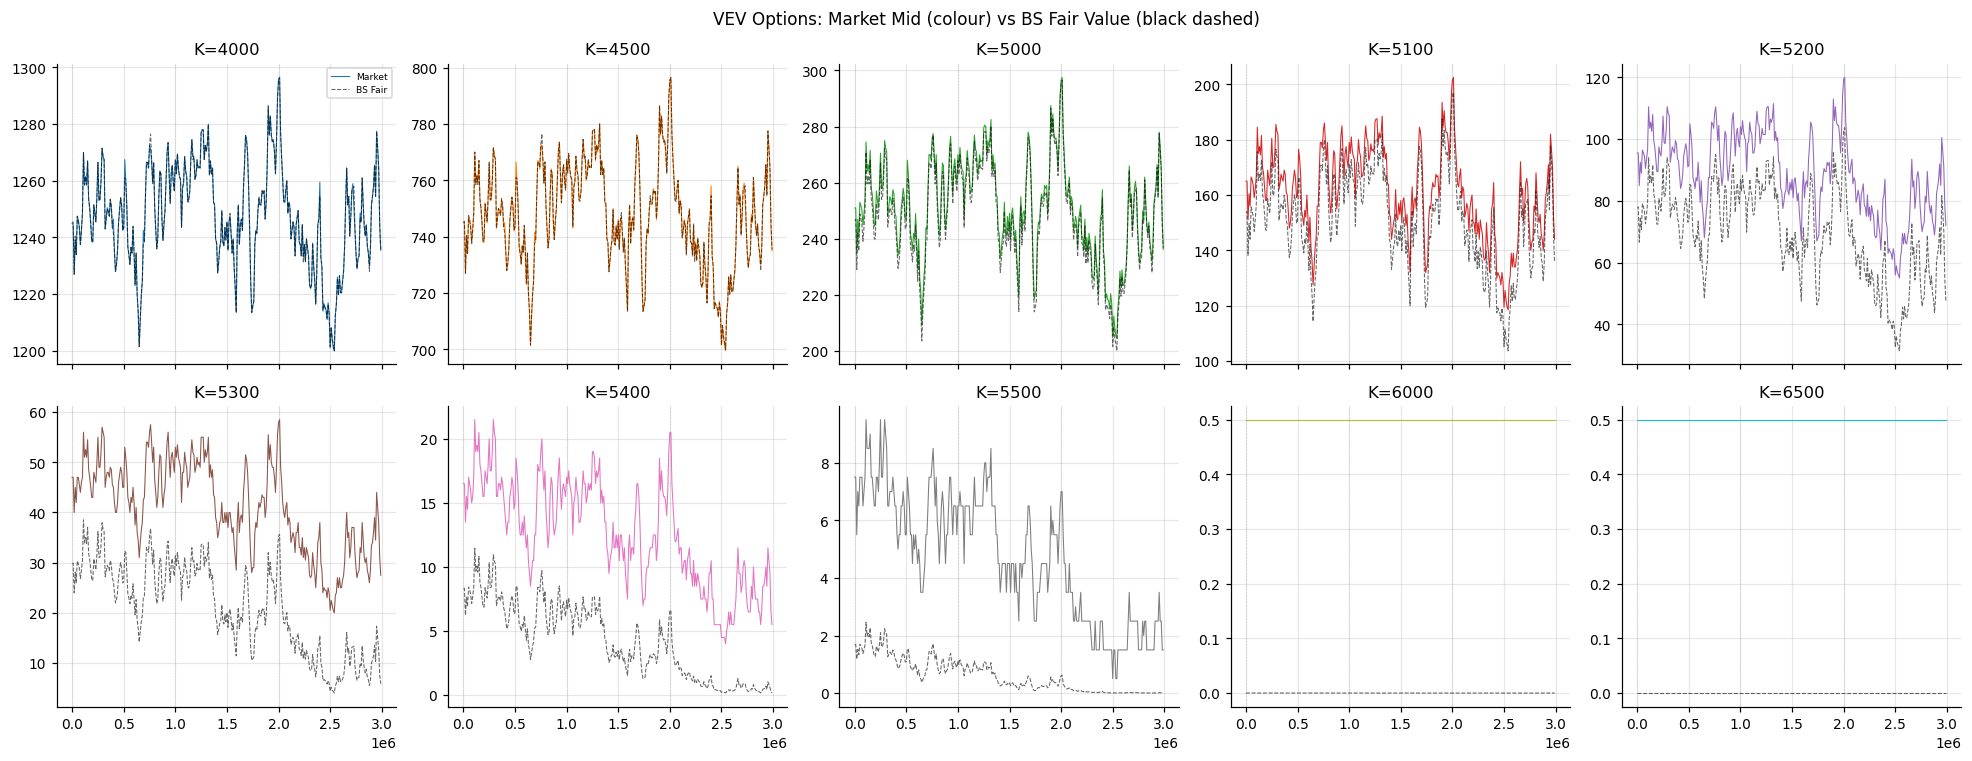

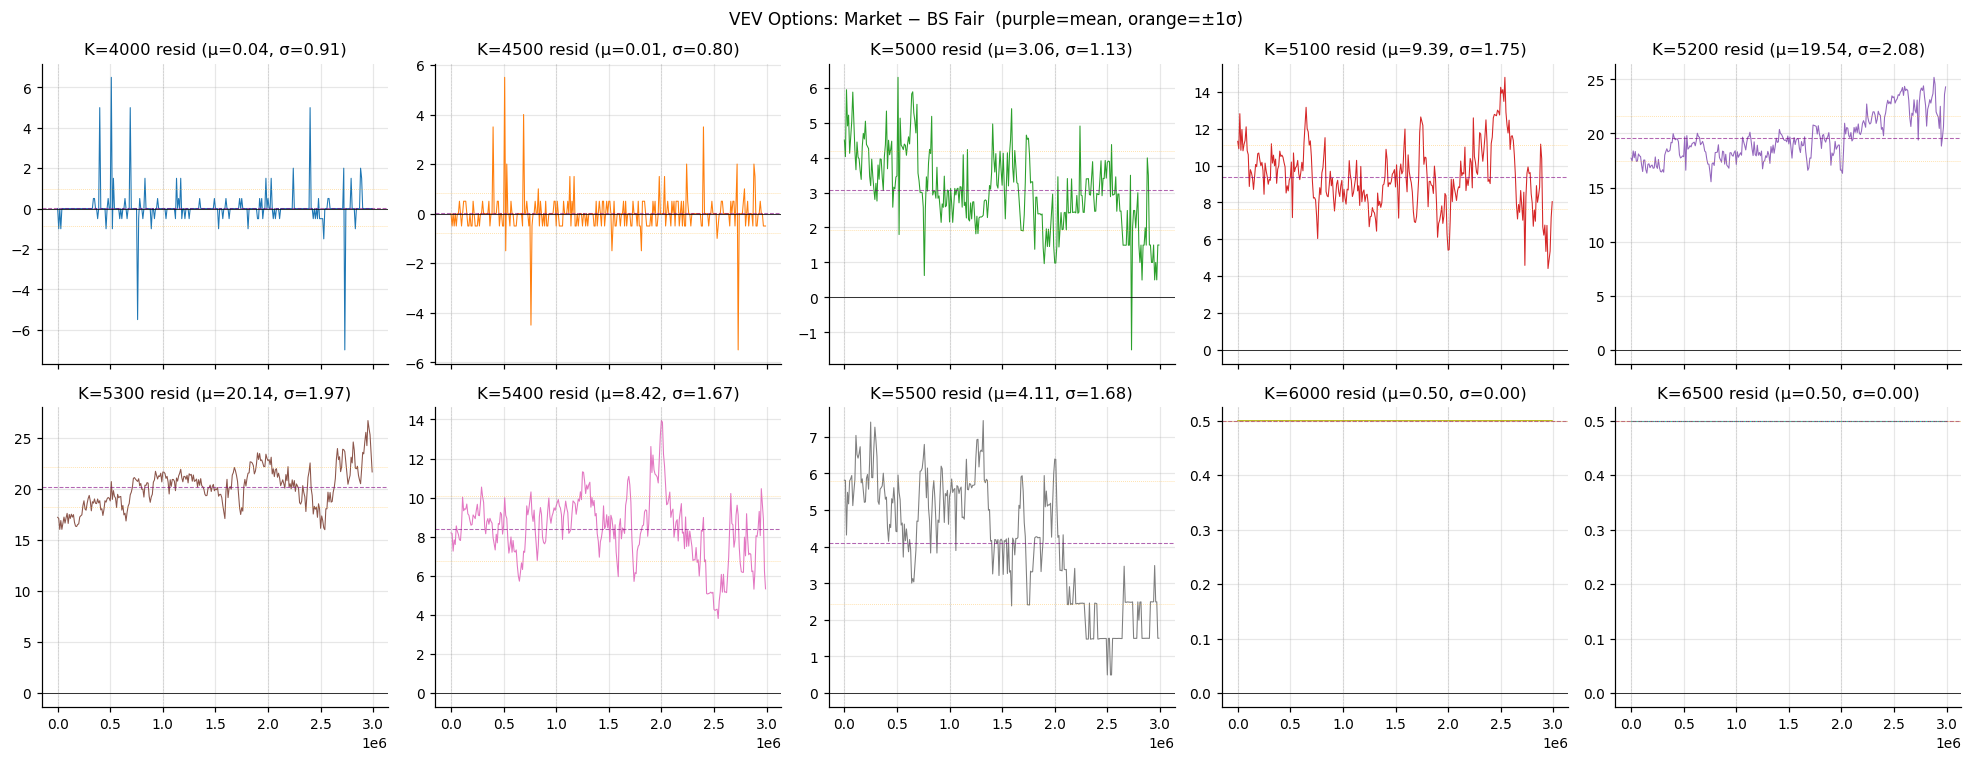

In [23]:
# Plot raw mid price vs BS fair value for each option (2×5 grid)
fig, axes = plt.subplots(2, 5, figsize=(18, 7), sharex=True)
axes = axes.flatten()

for i, (strike, ax) in enumerate(zip(STRIKES, axes)):
    opt = f'VEV_{strike}'
    if opt not in residuals:
        ax.set_title(f'K={strike}')
        continue
    ts_idx = all_ts
    ax.plot(ts_idx, mid_wide.loc[ts_idx, opt].values, lw=0.7, color=f'C{i}', label='Market')
    ax.plot(ts_idx, bs_fairs[opt].values, lw=0.7, color='black', ls='--', alpha=0.6, label='BS Fair')
    for ds in day_starts:
        ax.axvline(ds, color='gray', lw=0.4, ls='--', alpha=0.3)
    ax.set_title(f'K={strike}')
    if i == 0:
        ax.legend(fontsize=6)

plt.suptitle('VEV Options: Market Mid (colour) vs BS Fair Value (black dashed)', fontsize=11)
plt.tight_layout()
plt.show()

# Residual plots
fig, axes = plt.subplots(2, 5, figsize=(18, 7), sharex=True)
axes = axes.flatten()

for i, (strike, ax) in enumerate(zip(STRIKES, axes)):
    opt = f'VEV_{strike}'
    if opt not in residuals:
        ax.set_title(f'K={strike}')
        continue
    r = residuals[opt]
    ax.plot(r.index, r.values, lw=0.7, color=f'C{i}')
    ax.axhline(0,          color='black', lw=0.5)
    ax.axhline(r.mean(),   color='purple', lw=0.7, ls='--', alpha=0.6)
    ax.axhline(r.mean() + r.std(), color='orange', lw=0.5, ls=':', alpha=0.5)
    ax.axhline(r.mean() - r.std(), color='orange', lw=0.5, ls=':', alpha=0.5)
    for ds in day_starts:
        ax.axvline(ds, color='gray', lw=0.4, ls='--', alpha=0.3)
    ax.set_title(f'K={strike} resid (μ={r.mean():.2f}, σ={r.std():.2f})')

plt.suptitle('VEV Options: Market − BS Fair  (purple=mean, orange=±1σ)', fontsize=11)
plt.tight_layout()
plt.show()

In [25]:
if not HAS_SM:
    print('statsmodels not installed — skipping ADF tests')
else:
    adf_rows = []
    for strike in STRIKES:
        opt = f'VEV_{strike}'
        if opt not in residuals:
            continue
        r = residuals[opt].dropna().values
        if len(r) < 200:
            continue

        # ADF on raw mid price
        raw = mid_wide[opt].dropna().iloc[::SAMPLE_STEP].values[:len(r)]
        if raw.max() == raw.min() or r.max() == r.min():
            continue  # skip constant series (e.g. VEV_6000 / VEV_6500 stuck at 0)

        adf_raw   = adfuller(raw, maxlag=40, autolag='AIC')
        adf_resid = adfuller(r,   maxlag=40, autolag='AIC')

        adf_rows.append({
            'Option'         : opt,
            'Raw p-val'      : round(adf_raw[1],   4),
            'Raw stat (5%)'  : 'STAT' if adf_raw[1]   < 0.05 else 'NON-STAT',
            'Resid p-val'    : round(adf_resid[1], 4),
            'Resid stat (5%)': 'STAT' if adf_resid[1] < 0.05 else 'NON-STAT',
            'Resid Mean'     : round(residuals[opt].mean(), 3),
            'Resid Std'      : round(residuals[opt].std(),  3),
        })

    adf_df = pd.DataFrame(adf_rows).set_index('Option')
    print('ADF Test Results  (H0 = unit root = non-stationary, p<0.05 = stationary)')

    def color_stat(val):
        if val == 'STAT':     return 'background-color: lightgreen'
        if val == 'NON-STAT': return 'background-color: lightcoral'
        return ''

    display(adf_df.style
        .applymap(color_stat, subset=['Raw stat (5%)', 'Resid stat (5%)'])
        .format({'Raw p-val': '{:.4f}', 'Resid p-val': '{:.4f}'}))

ADF Test Results  (H0 = unit root = non-stationary, p<0.05 = stationary)


,Raw p-val,Raw stat (5%),Resid p-val,Resid stat (5%),Resid Mean,Resid Std
Option,,,,,,
VEV_4000,0.0014,STAT,0.0000,STAT,0.043000,0.910000
VEV_4500,0.0014,STAT,0.0000,STAT,0.013000,0.804000
VEV_5000,0.0023,STAT,0.0015,STAT,3.061000,1.133000
VEV_5100,0.0050,STAT,0.0001,STAT,9.388000,1.754000
VEV_5200,0.0248,STAT,0.6276,NON-STAT,19.544000,2.083000
VEV_5300,0.1204,NON-STAT,0.0018,STAT,20.143000,1.969000
VEV_5400,0.1412,NON-STAT,0.0045,STAT,8.418000,1.673000
VEV_5500,0.3427,NON-STAT,0.2979,NON-STAT,4.110000,1.682000


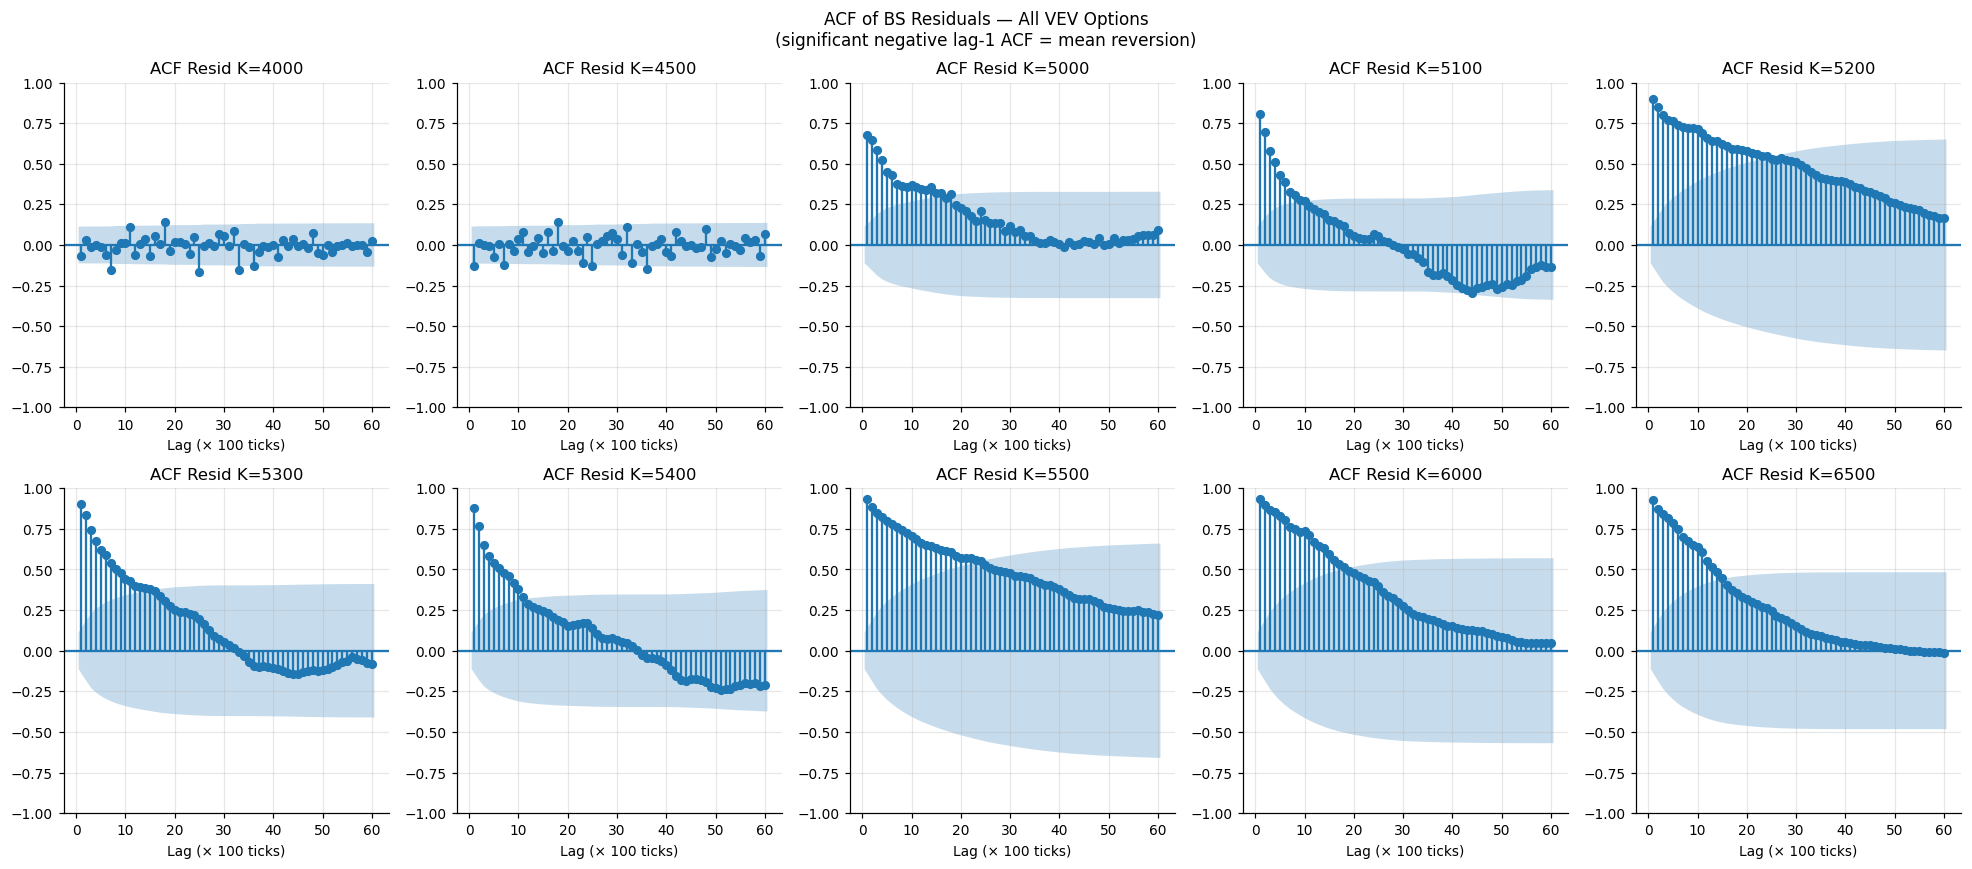

In [26]:
if not HAS_SM:
    print('statsmodels not installed — skipping ACF plots')
else:
    # ACF on residuals (market - BS fair)
    fig, axes = plt.subplots(2, 5, figsize=(18, 8))
    axes = axes.flatten()

    for i, strike in enumerate(STRIKES):
        opt = f'VEV_{strike}'
        ax = axes[i]
        if opt not in residuals:
            ax.set_title(f'K={strike}')
            continue
        r = residuals[opt].dropna()
        if len(r) < 60:
            continue
        plot_acf(r, lags=60, ax=ax, title=f'ACF Resid K={strike}', zero=False, alpha=0.05)
        ax.set_xlabel('Lag (× 100 ticks)')

    plt.suptitle('ACF of BS Residuals — All VEV Options\n(significant negative lag-1 ACF = mean reversion)', fontsize=11)
    plt.tight_layout()
    plt.show()

Half-Life of Mean Reversion (BS residuals)
HL (ticks): how many game ticks until residual reverts halfway to mean
HL (%day) : as % of one game-day (10,000 ticks total)


,Beta (AR1),p-value,HL (ticks),HL (%day),Mean Reverts
Option,,,,,
VEV_4000,-1.069980,0.000000,65.000000,0.650000,True
VEV_4500,-1.132310,0.000000,61.000000,0.610000,True
VEV_5000,-0.316540,0.000000,219.000000,2.190000,True
VEV_5100,-0.194410,0.000000,357.000000,3.570000,True
VEV_5200,-0.085860,0.000600,807.000000,8.070000,True
VEV_5300,-0.092400,0.000100,750.000000,7.500000,True
VEV_5400,-0.112200,0.000100,618.000000,6.180000,True
VEV_5500,-0.061370,0.002900,1129.000000,11.290000,True
VEV_6000,-0.065160,0.000100,1064.000000,10.640000,True


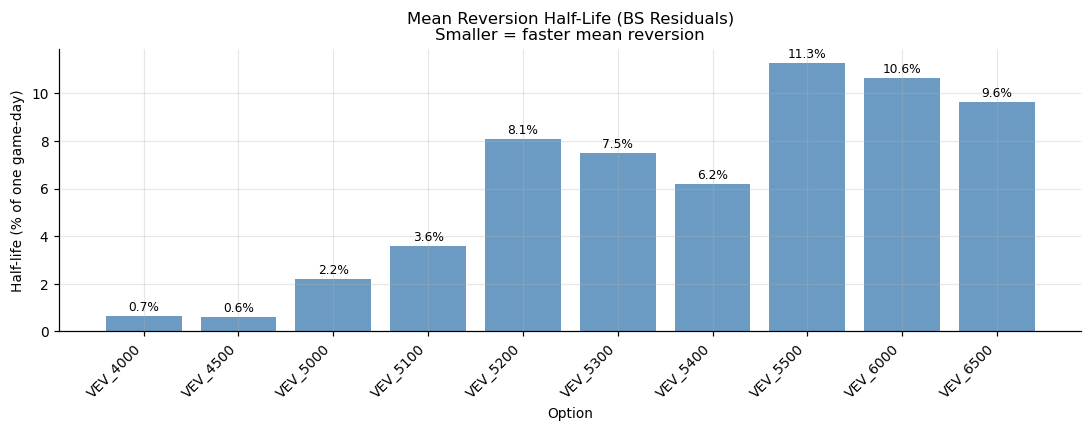

In [27]:
if not HAS_SM:
    print('statsmodels not installed — skipping half-life estimation')
else:
    # Fit OU model: dy = alpha + beta * y_{t-1} + eps
    # beta < 0 → mean-reverting, half-life = -ln(2)/beta (in sample units)
    # Each sample unit = SAMPLE_STEP * 100 timestamp units

    hl_rows = []
    for strike in STRIKES:
        opt = f'VEV_{strike}'
        if opt not in residuals:
            continue
        r = residuals[opt].dropna().values
        if len(r) < 100:
            continue

        y     = r[1:]
        y_lag = r[:-1]
        dy    = y - y_lag
        X = sm.add_constant(y_lag)
        try:
            res  = sm.OLS(dy, X).fit()
            beta = res.params[1]
            beta_pval = res.pvalues[1]
        except Exception:
            beta, beta_pval = 0, 1

        if beta < -1e-6:
            hl_samples = -math.log(2) / beta  # in sample-units
            # Each sample = SAMPLE_STEP * 100 timestamp units
            # 1 tick = 100 ts units, so hl in ticks = hl_samples * SAMPLE_STEP
            # Fraction of day = hl_ticks / 10000 (10k ticks per day)
            hl_ticks  = hl_samples * SAMPLE_STEP
            hl_pct_day = 100 * hl_ticks / 10000
        else:
            hl_ticks, hl_pct_day = float('inf'), float('inf')

        hl_rows.append({
            'Option'      : opt,
            'Beta (AR1)'  : round(beta, 5),
            'p-value'     : round(beta_pval, 4),
            'HL (ticks)'  : round(hl_ticks, 0) if hl_ticks < 1e6 else '>100k',
            'HL (%day)'   : round(hl_pct_day, 2) if hl_pct_day < 100 else '>100%',
            'Mean Reverts': beta < 0 and beta_pval < 0.05,
        })

    hl_df = pd.DataFrame(hl_rows).set_index('Option')
    print('Half-Life of Mean Reversion (BS residuals)')
    print('HL (ticks): how many game ticks until residual reverts halfway to mean')
    print('HL (%day) : as % of one game-day (10,000 ticks total)')
    display(hl_df.style.applymap(
        lambda v: 'background-color: lightgreen' if v is True else
                  ('background-color: lightcoral' if v is False else ''),
        subset=['Mean Reverts']
    ))

    # Bar chart of half-lives
    valid_hl = hl_df[hl_df['HL (%day)'] != '>100%'].copy()
    if len(valid_hl):
        fig, ax = plt.subplots(figsize=(10, 4))
        vals = pd.to_numeric(valid_hl['HL (%day)'], errors='coerce').dropna()
        ax.bar(vals.index, vals.values, color='steelblue', alpha=0.8)
        ax.set_ylabel('Half-life (% of one game-day)')
        ax.set_xlabel('Option')
        ax.set_title('Mean Reversion Half-Life (BS Residuals)\nSmaller = faster mean reversion')
        ax.set_xticklabels(vals.index, rotation=45, ha='right')
        for x_i, (opt_name, hl_val) in enumerate(zip(vals.index, vals.values)):
            ax.text(x_i, hl_val + 0.1, f'{hl_val:.1f}%', ha='center', va='bottom', fontsize=8)
        plt.tight_layout()
        plt.show()

## 7. Mean Reversion Backtest

Strategy: trade the **BS residual** back toward zero.

- Compute rolling z-score of residual (window = half-life from previous section, or 500 ticks default)
- Target position ∝ −z (short when residual is high, long when low)
- Position clipped to position limits: **300 per option**
- PnL = position_t × (price_{t+1} − price_t)  (no transaction costs — optimistic upper bound)

Note: this is run on the **sampled** series (every 100 ticks). Performance is an upper bound  
since real fills would require crossing the spread.

In [28]:
def mean_rev_backtest(price_series, resid_series, window=500, max_pos=280):
    '''
    Z-score mean reversion on the BS residual.
    price_series: raw option mid prices (for PnL calculation)
    resid_series: market price - BS fair (for signal)
    window      : rolling lookback in samples (100-tick each)
    max_pos     : maximum position (< 300 limit for buffer)
    Returns dict with arrays and summary stats.
    '''
    prices = price_series.values
    resid  = resid_series.values
    n = len(prices)
    if n < window + 10:
        return None

    roll_mean = pd.Series(resid).rolling(window).mean().values
    roll_std  = pd.Series(resid).rolling(window).std().values

    z = np.where(roll_std > 0.05, (resid - roll_mean) / roll_std, 0.0)

    # Target position: -clip(z * max_pos/2, -max_pos, max_pos)
    # z=+1 → short max_pos/2, z=+2 → short max_pos (fully short)
    target = -np.clip(z * max_pos / 2.0, -max_pos, max_pos)
    target[:window] = 0.0

    # PnL: position at t earns next-tick price change (no lag on signal)
    price_changes = np.concatenate([[0], np.diff(prices)])
    pnl_per_tick  = target * price_changes
    pnl_per_tick[0] = 0
    cum_pnl = np.cumsum(pnl_per_tick)

    active_pnl = pnl_per_tick[window:]
    sharpe = (active_pnl.mean() / active_pnl.std() * np.sqrt(len(active_pnl))
              if active_pnl.std() > 0 else 0.0)

    return {
        'prices'    : prices,
        'resid'     : resid,
        'z'         : z,
        'positions' : target,
        'pnl'       : pnl_per_tick,
        'cum_pnl'   : cum_pnl,
        'total_pnl' : cum_pnl[-1],
        'sharpe'    : sharpe,
        'window'    : window,
        'max_pos'   : max_pos,
    }

print('Backtest function defined.')

Backtest function defined.


In [29]:
# Determine window per option from half-life (default 500 if not available)
DEFAULT_WINDOW = 500  # in 100-tick samples

hl_windows = {}
if HAS_SM and 'hl_df' in dir():
    for opt in hl_df.index:
        hl_val = hl_df.loc[opt, 'HL (ticks)']
        if isinstance(hl_val, (int, float)) and hl_val < 1e5:
            # Convert hl in ticks to hl in samples (1 sample = SAMPLE_STEP ticks)
            hl_windows[opt] = max(50, min(int(hl_val / SAMPLE_STEP), 2000))
        else:
            hl_windows[opt] = DEFAULT_WINDOW

bt_results = {}
for strike in STRIKES:
    opt = f'VEV_{strike}'
    if opt not in residuals:
        continue
    price_s = mid_wide[opt].dropna().iloc[::SAMPLE_STEP].reindex(all_ts).ffill()
    resid_s = residuals[opt]
    common  = price_s.index.intersection(resid_s.index)
    if len(common) < 200:
        continue

    win = hl_windows.get(opt, DEFAULT_WINDOW)
    res = mean_rev_backtest(price_s.loc[common], resid_s.loc[common], window=win, max_pos=280)
    if res:
        bt_results[opt] = res
        print(f'{opt:12s}  win={win:4d}  total_pnl={res["total_pnl"]:+9.1f}  sharpe={res["sharpe"]:+.2f}')

VEV_4000      win=  50  total_pnl= -22214.1  sharpe=-1.45
VEV_4500      win=  50  total_pnl= -28611.1  sharpe=-1.84
VEV_5000      win=  50  total_pnl= +58804.9  sharpe=+2.80
VEV_5100      win=  50  total_pnl= +70611.8  sharpe=+3.69
VEV_5200      win=  50  total_pnl= +56113.0  sharpe=+4.14
VEV_5300      win=  50  total_pnl= -41493.1  sharpe=-4.51
VEV_5400      win=  50  total_pnl= -16790.6  sharpe=-4.52
VEV_5500      win=  50  total_pnl=  -8334.7  sharpe=-5.03
VEV_6000      win=  50  total_pnl=     +0.0  sharpe=+0.00
VEV_6500      win=  50  total_pnl=     +0.0  sharpe=+0.00


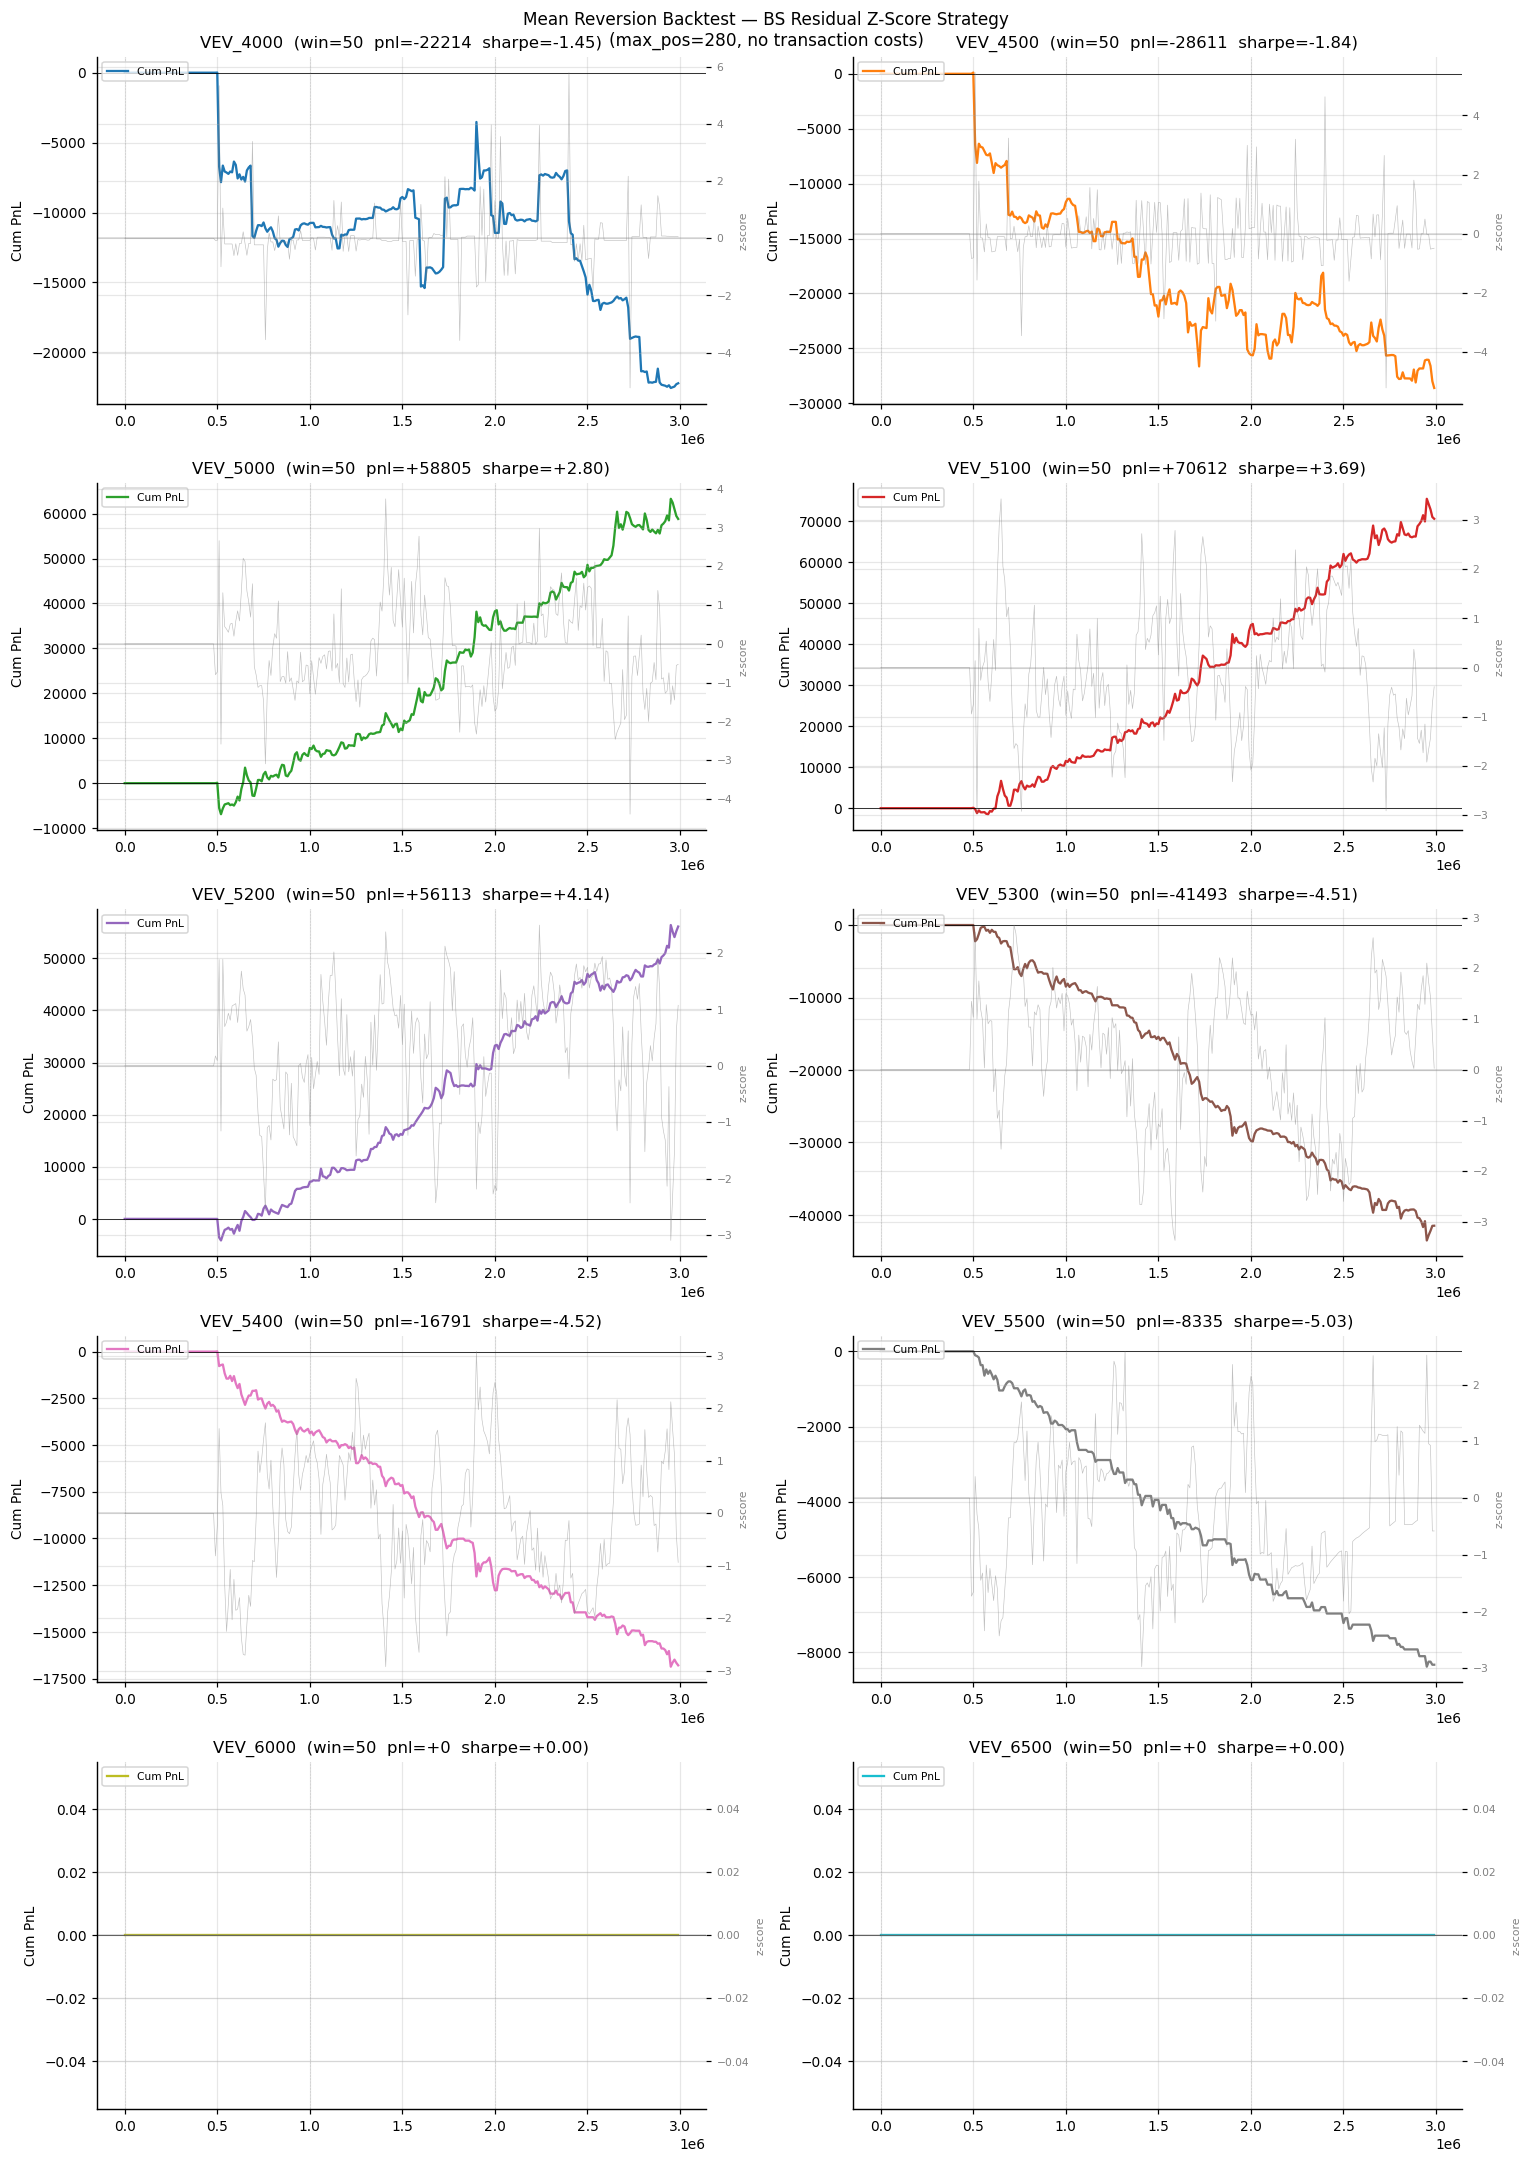

In [30]:
# Equity curves for each option backtest
n_opts = len(bt_results)
if n_opts == 0:
    print('No backtest results to plot.')
else:
    cols = 2
    rows = (n_opts + 1) // 2
    fig, axes = plt.subplots(rows, cols, figsize=(14, 4 * rows))
    axes = axes.flatten() if n_opts > 1 else [axes]

    for i, (opt, res) in enumerate(bt_results.items()):
        ax = axes[i]
        ts_idx = mid_wide[opt].dropna().iloc[::SAMPLE_STEP].index[:len(res['cum_pnl'])]

        ax2 = ax.twinx()
        ax2.plot(ts_idx, res['z'], color='gray', lw=0.4, alpha=0.5, label='z-score')
        ax2.axhline(0, color='gray', lw=0.3)
        ax2.set_ylabel('z-score', color='gray', fontsize=7)
        ax2.tick_params(axis='y', labelcolor='gray', labelsize=7)

        ax.plot(ts_idx, res['cum_pnl'], color=f'C{i}', lw=1.5, label='Cum PnL')
        ax.axhline(0, color='black', lw=0.5)
        for ds in day_starts:
            ax.axvline(ds, color='gray', lw=0.4, ls='--', alpha=0.3)
        ax.set_title(f'{opt}  (win={res["window"]}  pnl={res["total_pnl"]:+.0f}  sharpe={res["sharpe"]:+.2f})')
        ax.set_ylabel('Cum PnL')
        ax.legend(fontsize=7, loc='upper left')

    for ax in axes[n_opts:]:
        ax.set_visible(False)

    plt.suptitle('Mean Reversion Backtest — BS Residual Z-Score Strategy\n(max_pos=280, no transaction costs)', fontsize=11)
    plt.tight_layout()
    plt.show()

In [31]:
# Backtest summary table + position usage
if bt_results:
    bt_rows = []
    for opt, res in bt_results.items():
        pnl_arr = res['pnl']
        pos_arr = res['positions']
        active  = pnl_arr[res['window']:]
        bt_rows.append({
            'Option'      : opt,
            'Window'      : res['window'],
            'Total PnL'   : round(res['total_pnl'], 1),
            'Sharpe'      : round(res['sharpe'], 2),
            'PnL/tick'    : round(active.mean(), 4),
            'PnL std/tick': round(active.std(),  4),
            'Max Long'    : round(pos_arr.max(), 0),
            'Max Short'   : round(pos_arr.min(), 0),
            'Avg |Pos|'   : round(np.abs(pos_arr[res['window']:]).mean(), 1),
        })
    bt_sum = pd.DataFrame(bt_rows).set_index('Option')
    display(bt_sum.style
        .background_gradient(cmap='RdYlGn', subset=['Total PnL', 'Sharpe'])
        .format({
            'Total PnL': '{:+,.1f}', 'Sharpe': '{:+.2f}',
            'PnL/tick': '{:.4f}', 'PnL std/tick': '{:.4f}',
            'Max Long': '{:.0f}', 'Max Short': '{:.0f}', 'Avg |Pos|': '{:.1f}',
        })
    )

,Window,Total PnL,Sharpe,PnL/tick,PnL std/tick,Max Long,Max Short,Avg |Pos|
Option,,,,,,,,
VEV_4000,50,"-22,214.1",-1.45,-88.8564,970.1190,280,-280,49.4
VEV_4500,50,"-28,611.1",-1.84,-114.4445,984.1525,280,-280,76.6
VEV_5000,50,"+58,804.9",+2.80,235.2197,1326.6987,280,-280,127.5
VEV_5100,50,"+70,611.8",+3.69,282.4473,1209.8053,280,-280,133.2
VEV_5200,50,"+56,113.0",+4.14,224.4521,856.7951,280,-280,132.7
VEV_5300,50,"-41,493.1",-4.51,-165.9725,582.3264,280,-280,150.5
VEV_5400,50,"-16,790.6",-4.52,-67.1622,235.1279,280,-280,141.6
VEV_5500,50,"-8,334.7",-5.03,-33.3388,104.8411,280,-280,137.5
VEV_6000,50,+0.0,+0.00,0.0000,0.0000,0,-0,0.0


## 8. Cross-Option Spread Analysis

Some option pairs may be cointegrated even if the individual legs are not stationary.  
A spread (e.g. VEV_5200 − VEV_5300) might mean-revert faster than either leg alone,  
enabling a pairs-style strategy.

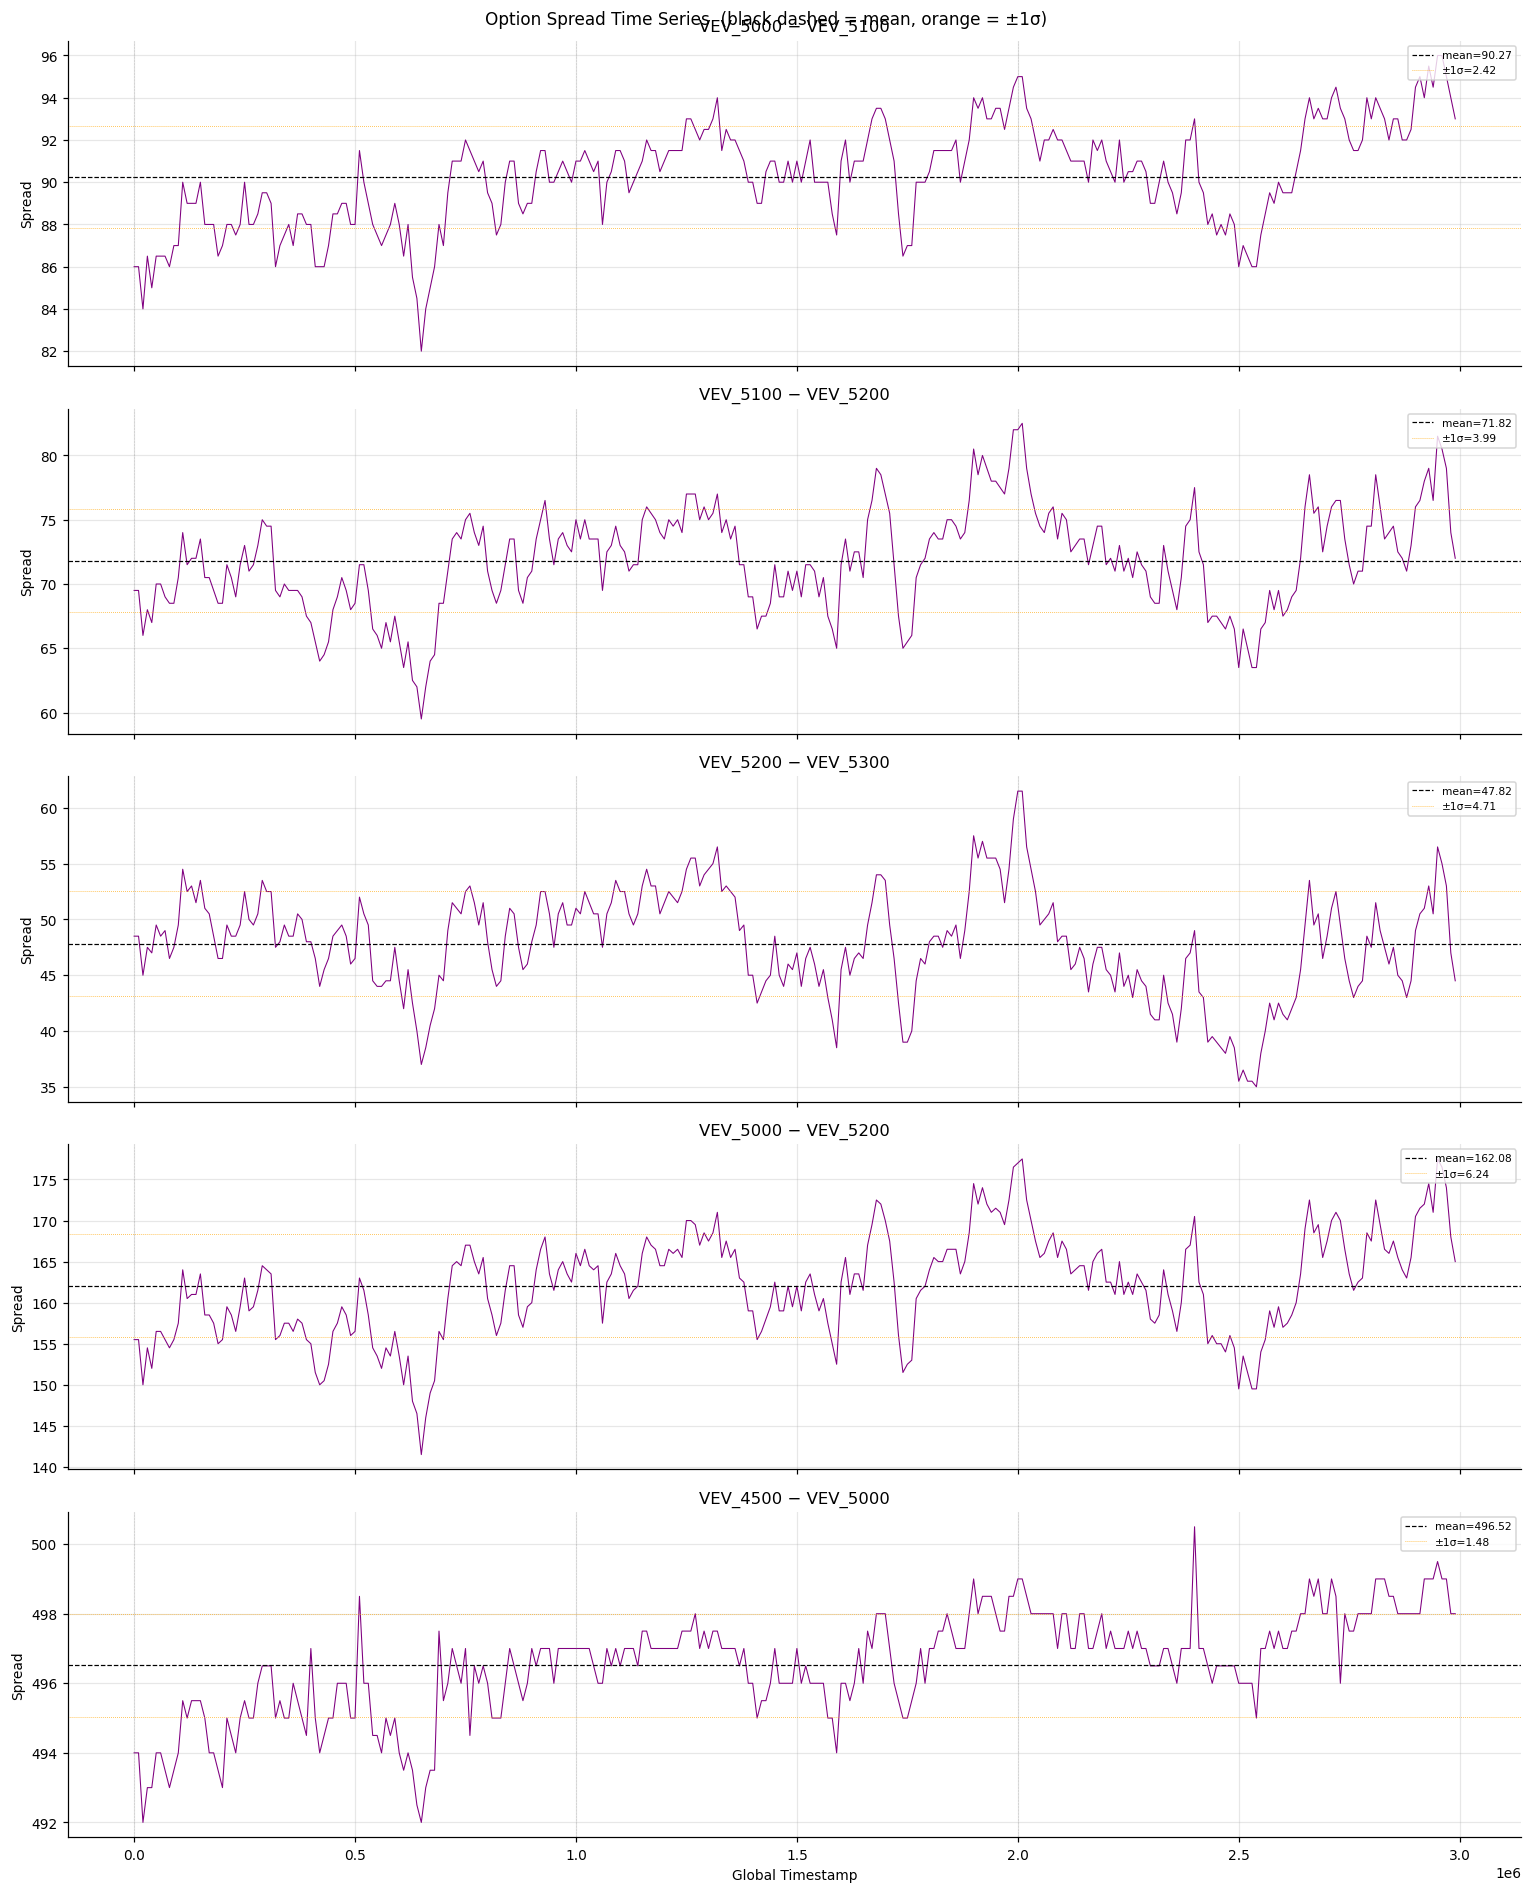


ADF Tests on Spreads:


,p-value,Stationary,Mean,Std
Spread,,,,
VEV_5000−VEV_5100,0.000900,True,90.265000,2.418000
VEV_5100−VEV_5200,0.000800,True,71.818000,3.993000
VEV_5200−VEV_5300,0.003700,True,47.817000,4.709000
VEV_5000−VEV_5200,0.002200,True,162.083000,6.237000
VEV_4500−VEV_5000,0.507300,False,496.518000,1.478000


In [32]:
spread_pairs = [
    ('VEV_5000', 'VEV_5100'),
    ('VEV_5100', 'VEV_5200'),
    ('VEV_5200', 'VEV_5300'),
    ('VEV_5000', 'VEV_5200'),
    ('VEV_4500', 'VEV_5000'),
]

fig, axes = plt.subplots(len(spread_pairs), 1, figsize=(14, 3.5 * len(spread_pairs)), sharex=True)

spread_adf = []
for ax, (opt_a, opt_b) in zip(axes, spread_pairs):
    if opt_a not in mid_wide.columns or opt_b not in mid_wide.columns:
        continue
    s_a = mid_wide[opt_a].iloc[::SAMPLE_STEP]
    s_b = mid_wide[opt_b].iloc[::SAMPLE_STEP]
    spread = s_a - s_b
    spread = spread.dropna()

    ax.plot(spread.index, spread.values, lw=0.7, color='purple')
    ax.axhline(spread.mean(), color='black', lw=0.8, ls='--', label=f'mean={spread.mean():.2f}')
    ax.axhline(spread.mean() + spread.std(), color='orange', lw=0.5, ls=':')
    ax.axhline(spread.mean() - spread.std(), color='orange', lw=0.5, ls=':', label=f'±1σ={spread.std():.2f}')
    for ds in day_starts:
        ax.axvline(ds, color='gray', lw=0.4, ls='--', alpha=0.3)
    ax.set_title(f'{opt_a} − {opt_b}')
    ax.set_ylabel('Spread')
    ax.legend(fontsize=7, loc='upper right')

    if HAS_SM and len(spread) > 100:
        p_val = adfuller(spread.values, maxlag=40, autolag='AIC')[1]
        spread_adf.append({'Spread': f'{opt_a}−{opt_b}', 'p-value': round(p_val, 4),
                           'Stationary': p_val < 0.05,
                           'Mean': round(spread.mean(), 3), 'Std': round(spread.std(), 3)})

axes[-1].set_xlabel('Global Timestamp')
plt.suptitle('Option Spread Time Series  (black dashed = mean, orange = ±1σ)', fontsize=11)
plt.tight_layout()
plt.show()

if spread_adf:
    spread_adf_df = pd.DataFrame(spread_adf).set_index('Spread')
    print('\nADF Tests on Spreads:')
    display(spread_adf_df.style.applymap(
        lambda v: 'background-color: lightgreen' if v is True else
                  ('background-color: lightcoral' if v is False else ''),
        subset=['Stationary']
    ))

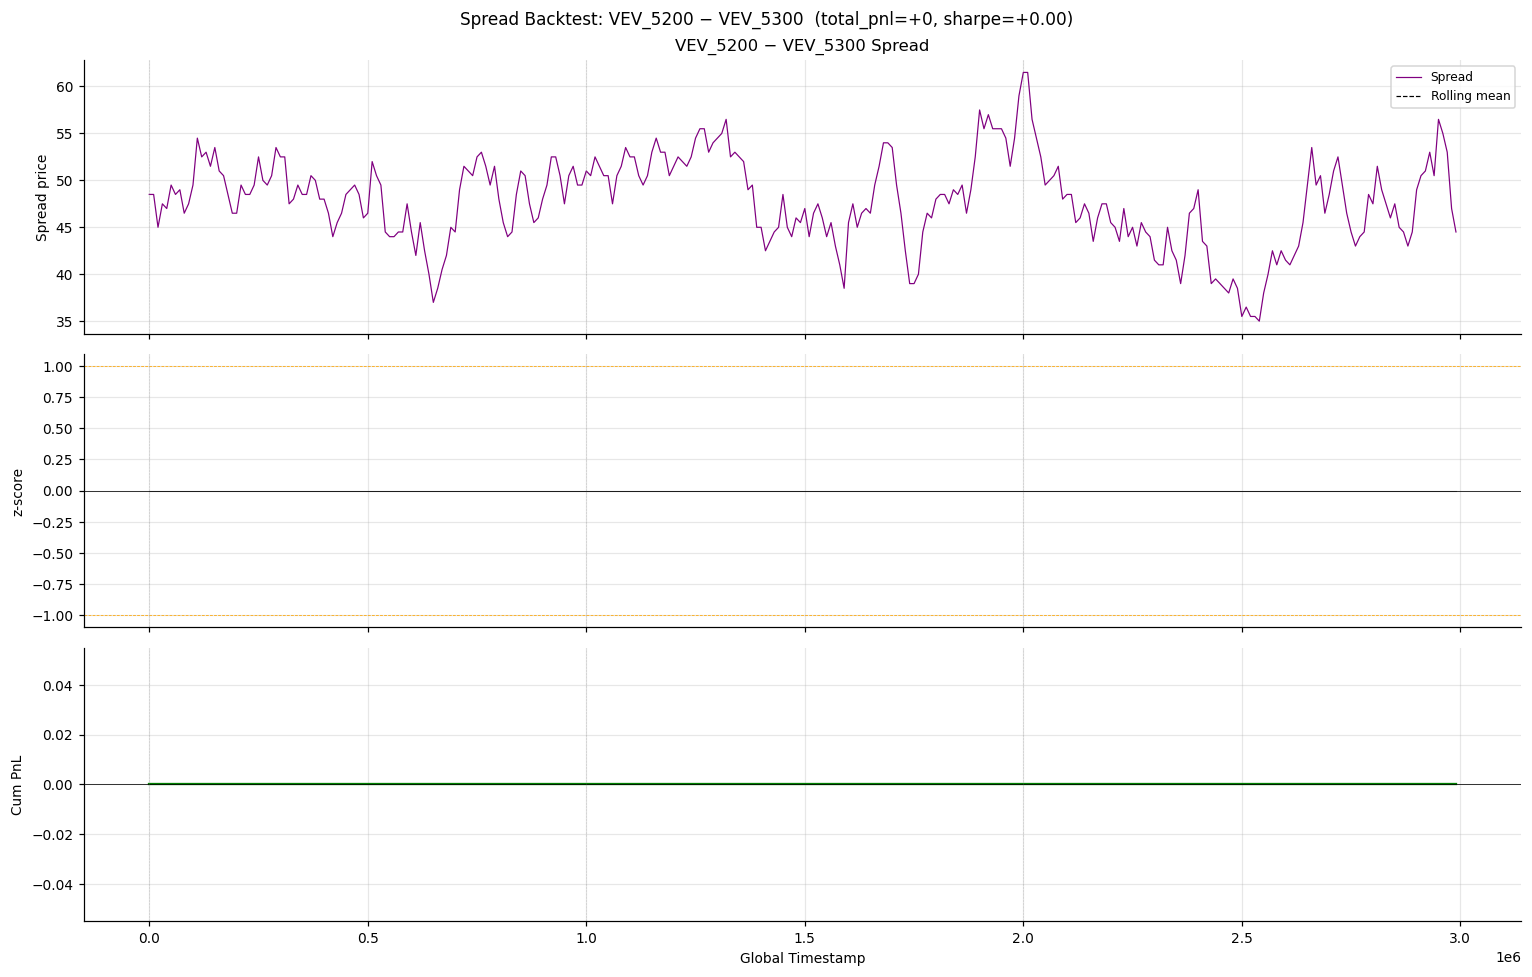

In [33]:
# Quick spread backtest: z-score on the best-looking spread
# Buy low-strike, sell high-strike when spread is below mean (spread tight)
# Reverse when spread is above mean (spread wide)

best_spread_pair = ('VEV_5200', 'VEV_5300')  # adjust based on ADF results above
opt_a, opt_b = best_spread_pair

if opt_a in mid_wide.columns and opt_b in mid_wide.columns:
    s_a = mid_wide[opt_a].iloc[::SAMPLE_STEP]
    s_b = mid_wide[opt_b].iloc[::SAMPLE_STEP]
    spread = (s_a - s_b).dropna()

    window = 500
    roll_mean = spread.rolling(window).mean()
    roll_std  = spread.rolling(window).std()
    z_spread  = ((spread - roll_mean) / roll_std.clip(lower=0.01)).fillna(0)

    # Position in spread: long (opt_a long, opt_b short) when z<0 (spread compressed)
    max_pos_spread = 150  # each leg capped at 150 (well within 300 limit)
    pos = -np.clip(z_spread.values * max_pos_spread / 2, -max_pos_spread, max_pos_spread)
    pos[:window] = 0

    # PnL from spread: pos × d(spread)
    d_spread = np.concatenate([[0], np.diff(spread.values)])
    pnl_spread = pos * d_spread
    cum_pnl_spread = np.cumsum(pnl_spread)

    fig, axes = plt.subplots(3, 1, figsize=(14, 9), sharex=True)

    axes[0].plot(spread.index, spread.values, color='purple', lw=0.8, label='Spread')
    axes[0].plot(spread.index, roll_mean.values, color='black', lw=0.8, ls='--', label='Rolling mean')
    axes[0].set_ylabel('Spread price')
    axes[0].set_title(f'{opt_a} − {opt_b} Spread')
    axes[0].legend(fontsize=8)

    axes[1].plot(spread.index, z_spread.values, color='gray', lw=0.7, label='z-score')
    axes[1].axhline(0, color='black', lw=0.5)
    axes[1].axhline(1, color='orange', lw=0.5, ls='--')
    axes[1].axhline(-1, color='orange', lw=0.5, ls='--')
    axes[1].set_ylabel('z-score')

    axes[2].plot(spread.index, cum_pnl_spread, color='green', lw=1.5, label='Cum PnL')
    axes[2].axhline(0, color='black', lw=0.5)
    axes[2].set_ylabel('Cum PnL')
    axes[2].set_xlabel('Global Timestamp')

    for ax in axes:
        for ds in day_starts:
            ax.axvline(ds, color='gray', lw=0.4, ls='--', alpha=0.3)

    active = pnl_spread[window:]
    sharpe = active.mean() / active.std() * np.sqrt(len(active)) if active.std() > 0 else 0
    plt.suptitle(f'Spread Backtest: {opt_a} − {opt_b}  '
                 f'(total_pnl={cum_pnl_spread[-1]:+.0f}, sharpe={sharpe:+.2f})', fontsize=11)
    plt.tight_layout()
    plt.show()